In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

#df = pd.read_csv('/data/home/anisha23/master-thesis/ETTh1.csv')
df = pd.read_csv('/content/drive/My Drive/Documents/ETTh1.csv')
print(df.shape)


(17420, 8)


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

features = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']

df[features] = scaler.fit_transform(df[features])

In [6]:
def create_sequences(data, target, seq_len=24, horizon=5):
    """
    data: [N, num_features]
    target: [N] (1D time series)
    """
    X, y = [], []
    for i in range(len(data) - seq_len - horizon + 1):
        X.append(data[i:i+seq_len])             # input window
        y.append(target[i+seq_len:i+seq_len+horizon])  # next H steps
    return np.array(X), np.array(y)


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split

X, y = create_sequences(df[features].values, df['OT'])

print(X.shape)
print(y.shape)

(17392, 24, 6)
(17392, 5)


In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Split train+val into train and val (e.g., 80% train, 20% val of original 80%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# Print shapes
print("X_train shape: ", X_train.shape)
print("X_val shape:   ", X_val.shape)
print("X_test shape:  ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_val shape: ", y_val.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (11130, 24, 6)
X_val shape:    (2783, 24, 6)
X_test shape:   (3479, 24, 6)
y_train shape:  (11130, 5)
y_val shape:  (2783, 5)
y_test shape:  (3479, 5)


In [9]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
horizon = 5
# ------------------------------
# 1. Fit scalers
# ------------------------------
input_scaler = StandardScaler()
target_scaler = StandardScaler()

# Scale inputs (fit on training set only)
X_train_scaled = input_scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val_scaled   = input_scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_scaled  = input_scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Scale targets
y_train_scaled = target_scaler.fit_transform(y_train)   # shape: (n_samples, horizon)
y_val_scaled   = target_scaler.transform(y_val)
y_test_scaled  = target_scaler.transform(y_test)



# ------------------------------
# 2. Convert to tensors
# ------------------------------
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_scaled = torch.tensor(y_train_scaled, dtype=torch.float32)

X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_scaled = torch.tensor(y_val_scaled, dtype=torch.float32)

X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_scaled = torch.tensor(y_test_scaled, dtype=torch.float32)

# ------------------------------
# 3. Create datasets & dataloaders
# ------------------------------
train_ds = TensorDataset(X_train, y_train_scaled)
val_ds   = TensorDataset(X_val, y_val_scaled)
test_ds  = TensorDataset(X_test, y_test_scaled)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=64)
test_dl  = DataLoader(test_ds, batch_size=64)


In [10]:
print("y_train shape:", y_train.shape)
print("Scaled y_train mean:", y_train_scaled.mean(axis=0))
print("Scaled y_train std:", y_train_scaled.std(axis=0))


y_train shape: (11130, 5)
Scaled y_train mean: tensor([0.0000e+00, 4.2843e-10, 8.1401e-10, 7.7117e-10, 2.0564e-09])
Scaled y_train std: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [11]:
print("\n(Input tensors)")
print("  Min:", torch.min(X_train).item(), "Max:", torch.max(X_train).item(),
      "Mean:", torch.mean(X_train.float()).item(), "Std:", torch.std(X_train.float()).item())

print("\n(Target tensors)")
print("  Min:", torch.min(y_train_scaled).item(), "Max:", torch.max(y_train_scaled).item(),
      "Mean:", torch.mean(y_train_scaled.float()).item(), "Std:", torch.std(y_train_scaled.float()).item())


(Input tensors)
  Min: -4.299349784851074 Max: 4.680425643920898 Mean: 8.568502157801916e-11 Std: 1.0000003576278687

(Target tensors)
  Min: -2.0254974365234375 Max: 3.814270496368408 Mean: 6.854801726241533e-10 Std: 1.0000089406967163


In [12]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.cluster import KMeans
# from collections import defaultdict

# class ProSeNetRegressor(nn.Module):
#     def __init__(self, input_dim, hidden_dim, num_prototypes, train_loader, horizon, dropout_prob=0.1, device='cpu'):
#         super(ProSeNetRegressor, self).__init__()
#         self.device = device

#         # Encoder (same as before)
#         self.encoder = nn.LSTM(
#             input_dim, hidden_dim, num_layers=3,
#             batch_first=True, bidirectional=True, dropout=dropout_prob
#         )
#         self.dropout = nn.Dropout(dropout_prob)

#         # Regression head: output a single continuous value
#         self.fc = nn.Linear(num_prototypes, horizon)

#         # Initialize model on device
#         self.to(self.device)

#          # Initialize prototypes (no class labels in regression)
#         self.prototypes = nn.Parameter(self.kmeans_init(train_loader, num_prototypes, hidden_dim))


#     def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
#         """Cluster all embeddings into prototypes (no per-class separation)."""
#         all_embeddings = []
#         self.eval()

#         with torch.no_grad():
#             for data, _ in train_loader:   # ignore labels (since regression target is continuous)
#                 data = data.to(self.device)
#                 _, (h_n, _) = self.encoder(data)
#                 h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#                 all_embeddings.append(h.cpu().numpy())

#         all_embeddings = np.vstack(all_embeddings)

#         # Run KMeans across all embeddings
#         kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
#         kmeans.fit(all_embeddings)
#         prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

#         return prototypes.to(self.device)

#     def forward(self, x):
#         x = x.to(self.device)
#         _, (h_n, _) = self.encoder(x)
#         h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#         h = self.dropout(h)

#         # Compute similarity to prototypes
#         dists = torch.cdist(h, self.prototypes, p=2)  # [B, num_prototypes]
#         sims = torch.exp(-dists ** 2)
#         #sims = torch.softmax(-dists, dim=1)

#         # Regression output
#         out = self.fc(sims)  # [B, H]
#         return out.squeeze(-1), sims, h   # return scalar predictions


In [13]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans

class ProSeNetRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_prototypes, train_loader, horizon, dropout_prob=0.1, device='cpu'):
        super(ProSeNetRegressor, self).__init__()
        self.device = device

        # Encoder
        self.encoder = nn.LSTM(
            input_dim, hidden_dim, num_layers=3,
            batch_first=True, bidirectional=True, dropout=dropout_prob
        )
        self.dropout = nn.Dropout(dropout_prob)

        # Forecasting head: now takes hidden state directly
        out_dim = hidden_dim * 2  # bidirectional → hidden_dim*2
        self.fc = nn.Linear(out_dim, horizon)

        # Initialize model on device
        self.to(self.device)

        # Initialize prototypes (moved to correct device!)
        proto_tensor = self.kmeans_init(train_loader, num_prototypes, hidden_dim)
        self.prototypes = nn.Parameter(proto_tensor.to(self.device))

    def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
        """Cluster embeddings into prototypes (CPU for sklearn, then back to torch)."""
        all_embeddings = []
        self.eval()

        with torch.no_grad():
            for data, _ in train_loader:
                data = data.to(self.device)                # ✅ FIX: ensure input is on same device as encoder
                _, (h_n, _) = self.encoder(data)
                h = torch.cat((h_n[-2], h_n[-1]), dim=1)   # [B, hidden_dim*2]
                all_embeddings.append(h.cpu().numpy())     # move back to CPU for sklearn

        all_embeddings = np.vstack(all_embeddings)

        # Run KMeans on CPU
        kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
        kmeans.fit(all_embeddings)
        prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

        return prototypes   # will be moved to self.device in __init__

    def forward(self, x):
        x = x.to(self.device)
        _, (h_n, _) = self.encoder(x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)   # [B, hidden_dim*2]
        h = self.dropout(h)

        # Prototype similarities (for interpretability)
        dists = torch.cdist(h, self.prototypes, p=2)  # [B, num_prototypes]
        sims = torch.exp(-dists ** 2)

        # Forecast from hidden state
        out = self.fc(h)

        return out, sims, h


In [14]:
## loss decrease over time as embeddings move closer to their nearest prototypes.

def clustering_loss(h, prototypes):
    h = F.normalize(h, dim=-1)
    prototypes = F.normalize(prototypes, dim=-1)

    # print(f"embeddings :\n{h}")
    # print(f"prototypes :\n{prototypes}")
    dists = torch.cdist(h, prototypes, p=2) ** 2  # square it explicitly
    # print(f"distance : \n{dists}")
    min_dists = torch.min(dists, dim=1)[0]
    return torch.mean(min_dists)

## every prototype should have at least one close data point

def evidence_loss(h, prototypes):
    h = F.normalize(h, dim=-1)
    prototypes = F.normalize(prototypes, dim=-1)
    dists = torch.cdist(prototypes, h, p=2) ** 2  # squared distances
    min_dists = torch.min(dists, dim=1)[0]        # min over encoded instances
    return torch.mean(min_dists)

## Penalizes too-close prototypes to avoid redundancy.
# Previous value of d_min = 2.5. Tried d_min=3.0. But its not giving good result
# Tried with 2.7 also, but the better result is with d_min = 2.5

# d_min = 1.0, 1.5,

def diversity_loss(prototypes, d_min=1.0):
    prototypes = F.normalize(prototypes, dim=-1)
    dists = torch.cdist(prototypes, prototypes)
    mask = torch.triu(torch.ones_like(dists), diagonal=1)
    penalty = F.relu(d_min - dists) ** 2
    return torch.sum(penalty * mask) / (prototypes.shape[0] * (prototypes.shape[0] - 1) / 2)

#     return torch.sum(penalty * mask)

def sparsity_loss(fc):
    return torch.norm(fc.weight, p=1)



In [15]:
model = ProSeNetRegressor(input_dim=6, hidden_dim=64, num_prototypes=5,  train_loader=train_dl, horizon=24, device=device)
model.to(device)

ProSeNetRegressor(
  (encoder): LSTM(6, 64, num_layers=3, batch_first=True, dropout=0.1, bidirectional=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=24, bias=True)
)

In [16]:
def compute_intra_inter_distances(dtw_matrix, cluster_labels, medoids):
    # Organize cluster members
    clusters = defaultdict(list)
    for idx, label in enumerate(cluster_labels):
        clusters[label].append(idx)

    intra_distances = {}
    for label, indices in clusters.items():
        medoid_idx = medoids[label]
        total_distance = 0.0
        for i in indices:
            if i != medoid_idx:
                total_distance += dtw_matrix[medoid_idx, i]

        avg_intra_dist = total_distance / (len(indices)-1) if len(indices) > 1 else 0.0
        intra_distances[label] = avg_intra_dist

    # Compute Inter-cluster distances between medoids
    inter_distances = {}
    for (label1, medoid1), (label2, medoid2) in combinations(medoids.items(), 2):
        inter_distances[(label1, label2)] = dtw_matrix[medoid1, medoid2]

    return intra_distances, inter_distances


In [17]:
def project_prototypes(model, dataloader):
    model.eval()
    with torch.no_grad():
        all_inputs = []
        all_embeddings = []

        for inputs, _ in dataloader:
            inputs = inputs.to(device)
            _, _, h = model(inputs)
            all_inputs.append(inputs)
            all_embeddings.append(h)

        all_inputs = torch.cat(all_inputs, dim=0)
        all_embeddings = torch.cat(all_embeddings, dim=0)

        closest_inputs = []

        for i in range(model.prototypes.shape[0]):
            proto = model.prototypes[i].unsqueeze(0)
            dists = torch.norm(all_embeddings - proto, dim=1)
            closest_idx = torch.argmin(dists)
            closest_input = all_inputs[closest_idx]
            closest_inputs.append(closest_input)

        return closest_inputs


In [18]:
# # previous value of diversity penalty is 1.0
# def training(model, train_loader, val_loader,criterion,optimizer,num_epochs,lambda_c, lambda_e, lambda_d):
#     train_losses = []
#     val_losses = []
#     train_accs = []
#     val_accs = []
#     sim_scores_per_epoch = []

#     mse_losses, clust_losses, evid_losses, div_losses = [], [], [], []
#     all_embeddings = []
#     all_labels = []

#     model.to(device)

#     for epoch in range(num_epochs):
#         model.train()
#         running_train_loss = 0.0
#         train_correct = 0.0
#         train_total = 0.0

#         mse_loss_epoch = 0.0
#         clust_loss_epoch = 0.0
#         evid_loss_epoch = 0.0
#         div_loss_epoch = 0.0

#         sim_scores_epoch = []
#         epoch_embeddings = []
#         epoch_labels = []


#         for batch in train_loader:
#             inputs, targets = batch
#             inputs, targets = inputs.to(device), targets.to(device).float()
#             preds, sims, h = model(inputs)

#             mse_loss = criterion(preds, targets.float())
#             # print(f"ce loss : {ce_loss}")
#             clust_loss = clustering_loss(h, model.prototypes)
#             # print(f"clust loss : {clust_loss}")
#             evid_loss = evidence_loss(h, model.prototypes)
#             # print(f"evid loss : {evid_loss}")
#             # div_loss = diversity_loss(model.prototypes)
#             div_loss = diversity_loss(model.prototypes)
#             # print(f"div loss : {div_loss}")
#             # l1_loss = sparsity_loss(model.fc)

#             # lambda_e = lambda_e_schedule(epoch)
#             loss = (mse_loss +
#                     lambda_c * clust_loss +
#                     lambda_e * evid_loss +
#                     lambda_d * div_loss )

#             optimizer.zero_grad()
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()

#             if hasattr(model, 'fc'):
#                 for param in model.fc.parameters():
#                     param.data.clamp_(min=0.0)

#             running_train_loss += loss.item()
#             mse_loss_epoch += mse_loss.item()
#             clust_loss_epoch += clust_loss.item()
#             evid_loss_epoch += evid_loss.item()
#             div_loss_epoch += div_loss.item()

#             sim_scores_epoch.append(sims.detach().cpu())
#             epoch_embeddings.append(h.detach().cpu())
#             epoch_labels.append(targets.detach().cpu())

#         avg_train_loss = running_train_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         mse_losses.append(mse_loss_epoch / len(train_loader))
#         clust_losses.append(clust_loss_epoch / len(train_loader))
#         evid_losses.append(evid_loss_epoch / len(train_loader))
#         div_losses.append(div_loss_epoch / len(train_loader))

#         sim_scores_per_epoch.append(torch.cat(sim_scores_epoch, dim=0))
#         all_embeddings = torch.cat(epoch_embeddings, dim=0)
#         all_labels = torch.cat(epoch_labels, dim=0)

#         # ---- Validation ----
#         model.eval()
#         running_val_loss = 0.0
#         val_correct = 0
#         val_total = 0

#         with torch.no_grad():
#             for batch in val_loader:
#                 inputs, targets = batch
#                 inputs, targets = inputs.to(device), targets.to(device).float()
#                 preds, sims, h = model(inputs)
#                 val_loss = criterion(preds, targets.float())
#                 running_val_loss += val_loss.item()

#         avg_val_loss = running_val_loss / len(val_loader)
#         val_losses.append(avg_val_loss)

#         print(f"Epoch {epoch+1}/{num_epochs} "
#               f"Total Train Loss: {avg_train_loss:.4f}"
#               f"| Val Loss: {avg_val_loss:.4f}")

#     return (train_losses, val_losses, mse_losses, clust_losses, evid_losses, div_losses,
#             sim_scores_per_epoch, all_embeddings, all_labels)


In [19]:
# Updated training function for multi-horizon targets
def training(model, train_loader, val_loader, criterion, optimizer,
             num_epochs, lambda_c, lambda_e, lambda_d, target_scaler):
    train_losses = []
    val_losses = []
    train_mse_orig = []   # Track train MSE in original scale
    val_mse_orig = []     # Track val MSE in original scale

    mse_losses, clust_losses, evid_losses, div_losses = [], [], [], []
    sim_scores_per_epoch = []
    all_embeddings, all_labels = [], []

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        mse_loss_epoch = 0.0
        clust_loss_epoch = 0.0
        evid_loss_epoch = 0.0
        div_loss_epoch = 0.0

        sim_scores_epoch = []
        epoch_embeddings = []
        epoch_labels = []
        orig_preds_epoch = []
        orig_targets_epoch = []

        # -----------------------------
        # Training loop
        # -----------------------------
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device).float()  # targets shape: (B, horizon)
            preds, sims, h = model(inputs)  # preds shape: (B, horizon)

            # Losses in scaled space
            mse_loss = criterion(preds, targets)
            clust_loss = clustering_loss(h, model.prototypes)
            evid_loss = evidence_loss(h, model.prototypes)
            div_loss = diversity_loss(model.prototypes)

            loss = (mse_loss +
                    lambda_c * clust_loss +
                    lambda_e * evid_loss +
                    lambda_d * div_loss)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if hasattr(model, 'fc'):
                for param in model.fc.parameters():
                    param.data.clamp_(min=0.0)

            # Track scaled-space losses
            running_train_loss += loss.item()
            mse_loss_epoch += mse_loss.item()
            clust_loss_epoch += clust_loss.item()
            evid_loss_epoch += evid_loss.item()
            div_loss_epoch += div_loss.item()

            sim_scores_epoch.append(sims.detach().cpu())
            epoch_embeddings.append(h.detach().cpu())
            epoch_labels.append(targets.detach().cpu())

            # ---- NEW: track inverse-transformed predictions (multi-horizon) ----
            # preds_np and targets_np will be shape (B, horizon)
            preds_np = preds.detach().cpu().numpy()
            targets_np = targets.detach().cpu().numpy()

            # inverse_transform expects shape (B, horizon) if fitted on (n_samples, horizon)
            preds_orig = target_scaler.inverse_transform(preds_np)    # shape (B, horizon)
            targets_orig = target_scaler.inverse_transform(targets_np) # shape (B, horizon)

            # Flatten and accumulate for epoch-level metrics
            orig_preds_epoch.extend(preds_orig.reshape(-1))   # length B*horizon
            orig_targets_epoch.extend(targets_orig.reshape(-1))

        # Average training losses
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        mse_losses.append(mse_loss_epoch / len(train_loader))
        clust_losses.append(clust_loss_epoch / len(train_loader))
        evid_losses.append(evid_loss_epoch / len(train_loader))
        div_losses.append(div_loss_epoch / len(train_loader))

        # safe concat (only if non-empty)
        if len(sim_scores_epoch) > 0:
            sim_scores_per_epoch.append(torch.cat(sim_scores_epoch, dim=0))
        else:
            sim_scores_per_epoch.append(torch.tensor([]))

        if len(epoch_embeddings) > 0:
            all_embeddings = torch.cat(epoch_embeddings, dim=0)
        else:
            all_embeddings = torch.tensor([])

        if len(epoch_labels) > 0:
            all_labels = torch.cat(epoch_labels, dim=0)
        else:
            all_labels = torch.tensor([])

        # Compute train MSE in original scale (flattened across all horizons)
        train_mse_epoch_orig = np.mean((np.array(orig_preds_epoch) -
                                        np.array(orig_targets_epoch)) ** 2)
        train_mse_orig.append(train_mse_epoch_orig)

        # -----------------------------
        # Validation loop
        # -----------------------------
        model.eval()
        running_val_loss = 0.0
        orig_preds_val = []
        orig_targets_val = []

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device).float()
                preds, sims, h = model(inputs)

                # Loss in scaled space
                val_loss = criterion(preds, targets)
                running_val_loss += val_loss.item()

                # inverse transform (multi-horizon)
                preds_np = preds.detach().cpu().numpy()      # (B, horizon)
                targets_np = targets.detach().cpu().numpy()  # (B, horizon)

                preds_orig = target_scaler.inverse_transform(preds_np)
                targets_orig = target_scaler.inverse_transform(targets_np)

                orig_preds_val.extend(preds_orig.reshape(-1))
                orig_targets_val.extend(targets_orig.reshape(-1))

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Compute val MSE in original scale
        val_mse_epoch_orig = np.mean((np.array(orig_preds_val) -
                                      np.array(orig_targets_val)) ** 2)
        val_mse_orig.append(val_mse_epoch_orig)

        # -----------------------------
        # Logging
        # -----------------------------
        print(f"Epoch {epoch+1}/{num_epochs} "
              f"| Train Loss (scaled): {avg_train_loss:.6f} "
              f"| Val Loss (scaled): {avg_val_loss:.6f} "
              f"| Train MSE (orig): {train_mse_epoch_orig:.6f} "
              f"| Val MSE (orig): {val_mse_epoch_orig:.6f}")

    return (train_losses, val_losses, mse_losses, clust_losses, evid_losses,
            div_losses, sim_scores_per_epoch, all_embeddings, all_labels,
            train_mse_orig, val_mse_orig)


In [ ]:
# # for n_prototypes in [7, 8, 9, 10, 12, 15, 20]:

# n_prototypes = 10
# horizon=5

# print(f"PROSENET TRAINING WITH {n_prototypes} PROTOTYPES\n")
# print("***************************************************")

# model = ProSeNetRegressor(input_dim=6, hidden_dim=64, num_prototypes=n_prototypes,  train_loader=train_dl, horizon=horizon, device=device)

# criterion = torch.nn.MSELoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=.0001, weight_decay=1e-5)
# #optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)

# num_epochs = 100

# # lambda_c=0.3
# # lambda_c=0.2
# lambda_c=0.4

# # lambda_e=0.5
# # lambda_e=0.4
# lambda_e=0.3

# lambda_d=0.1
# # lambda_d=0.3
# # lambda_d=0.2

# (train_losses, val_losses, mse_losses, clust_losses, evid_losses, div_losses, sim_scores, input_embeddings, all_labels) = training(
#     model, train_dl, val_dl,criterion, optimizer, num_epochs, lambda_c, lambda_e, lambda_d)


In [21]:
n_prototypes = 5
horizon =5

print(f"PROSENET TRAINING WITH {n_prototypes} PROTOTYPES\n")
print("***************************************************")

model = ProSeNetRegressor(
    input_dim=6,
    hidden_dim=64,
    num_prototypes=n_prototypes,
    train_loader=train_dl,
    horizon=horizon,
    device=device
)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=1e-5)

num_epochs = 100

# lambda_c = 0.4
# lambda_e = 0.3
# lambda_d = 0.1

lambda_c = 0.1
lambda_e = 0.1
lambda_d = 0.05

# -----------------------------
# Run training
# -----------------------------
(train_losses, val_losses,
 mse_losses, clust_losses, evid_losses, div_losses,
 sim_scores, input_embeddings, all_labels,
 train_mse_orig, val_mse_orig) = training(
    model,
    train_dl,
    val_dl,
    criterion,
    optimizer,
    num_epochs,
    lambda_c,
    lambda_e,
    lambda_d,
    target_scaler  # <--- NEW
)


PROSENET TRAINING WITH 5 PROTOTYPES

***************************************************
Epoch 1/100 | Train Loss (scaled): 0.623061 | Val Loss (scaled): 0.376853 | Train MSE (orig): 43.096645 | Val MSE (orig): 27.472040
Epoch 2/100 | Train Loss (scaled): 0.308386 | Val Loss (scaled): 0.297262 | Train MSE (orig): 20.709663 | Val MSE (orig): 21.887388
Epoch 3/100 | Train Loss (scaled): 0.237169 | Val Loss (scaled): 0.185729 | Train MSE (orig): 15.493954 | Val MSE (orig): 13.754285
Epoch 4/100 | Train Loss (scaled): 0.200446 | Val Loss (scaled): 0.164793 | Train MSE (orig): 12.863120 | Val MSE (orig): 12.214932
Epoch 5/100 | Train Loss (scaled): 0.181693 | Val Loss (scaled): 0.158934 | Train MSE (orig): 11.568503 | Val MSE (orig): 11.785628
Epoch 6/100 | Train Loss (scaled): 0.167171 | Val Loss (scaled): 0.137328 | Train MSE (orig): 10.534374 | Val MSE (orig): 10.164344
Epoch 7/100 | Train Loss (scaled): 0.145184 | Val Loss (scaled): 0.124127 | Train MSE (orig): 8.975260 | Val MSE (orig)

In [22]:
## To check the scale of different losses

losses = {
    "Total Train Loss": train_losses,
    "MSE Loss": mse_losses,
    "Clustering Loss": clust_losses,
    "Evidence Loss": evid_losses,
    "Diversity Loss": div_losses,
    "Validation Loss": val_losses
}

for name, loss in losses.items():
    print(f"{name:>20}: min={np.min(loss):.4f}, max={np.max(loss):.4f}, mean={np.mean(loss):.4f}")


    Total Train Loss: min=0.0288, max=0.6231, mean=0.0633
            MSE Loss: min=0.0160, max=0.5846, mean=0.0476
     Clustering Loss: min=0.1103, max=0.2043, mean=0.1239
       Evidence Loss: min=0.0154, max=0.1194, mean=0.0284
      Diversity Loss: min=0.0024, max=0.1218, mean=0.0087
     Validation Loss: min=0.0164, max=0.3769, mean=0.0482


In [23]:
import matplotlib.pyplot as plt

def plot_training_curves(loss_dict):

    epochs = range(1, len(next(iter(loss_dict.values()))) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Losses
    plt.subplot(1, 2, 1)
    for label, loss in loss_dict.items():
        plt.plot(epochs, loss, label=label)
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()



# Plot the original losses to see the true maginitude of the losses

In [24]:
loss_dict={
        'Train MSE Loss': mse_losses,
        'Val MSE Loss': val_losses
    }

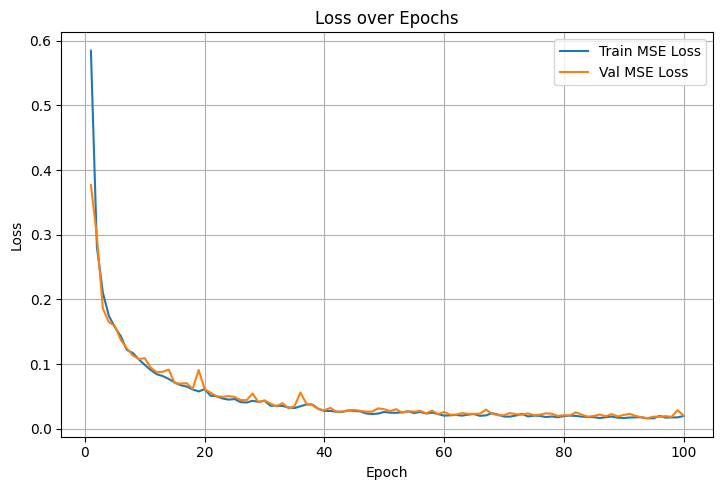

In [25]:
plot_training_curves(loss_dict)

# Plot the normalized losses to check shape or trend of the losses

In [26]:
## Scale the losses using MinMax Scaler to make them in uniform scale
from sklearn.preprocessing import MinMaxScaler
loss_scaler = MinMaxScaler()

losses = np.array([train_losses, val_losses, mse_losses, clust_losses, evid_losses, div_losses])
scaled_losses = loss_scaler.fit_transform(losses.T).T

In [27]:
loss_dict_scaled={
        'Train Cross-Entropy': scaled_losses[2],
        'Val Cross-Entropy': scaled_losses[1]
    }

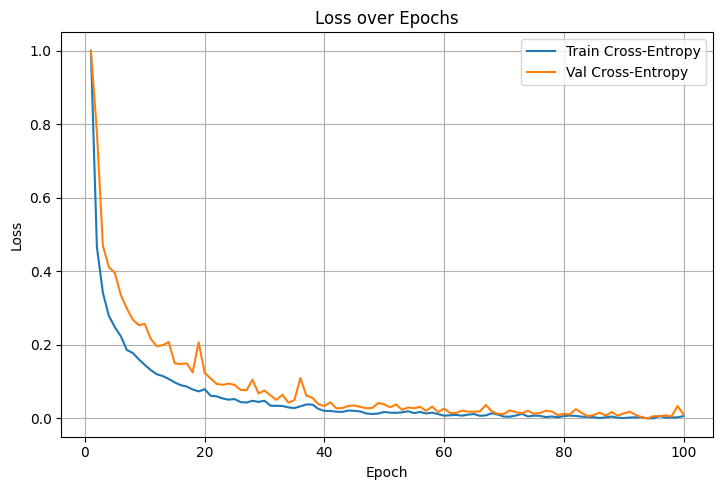

In [28]:
plot_training_curves(loss_dict_scaled)

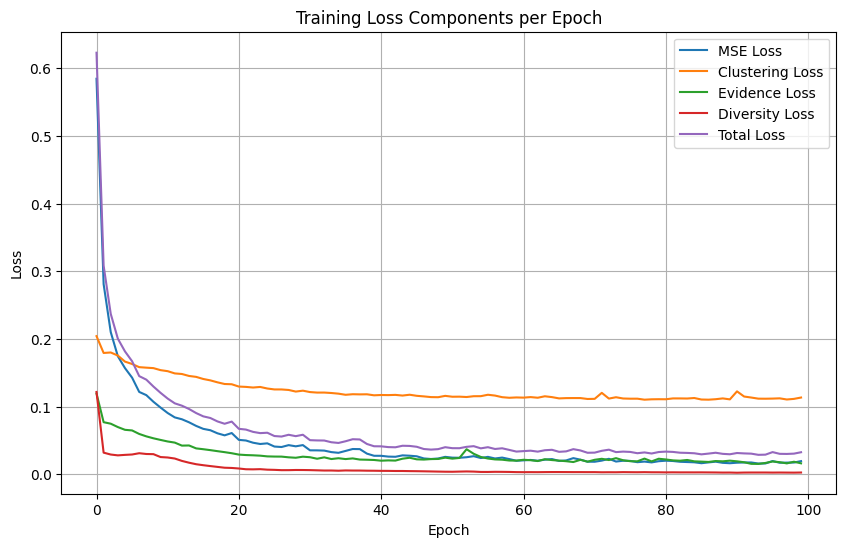

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(mse_losses, label='MSE Loss')
plt.plot(clust_losses, label='Clustering Loss')
plt.plot(evid_losses, label='Evidence Loss')
plt.plot(div_losses, label='Diversity Loss')
plt.plot(train_losses, label='Total Loss')

plt.title("Training Loss Components per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

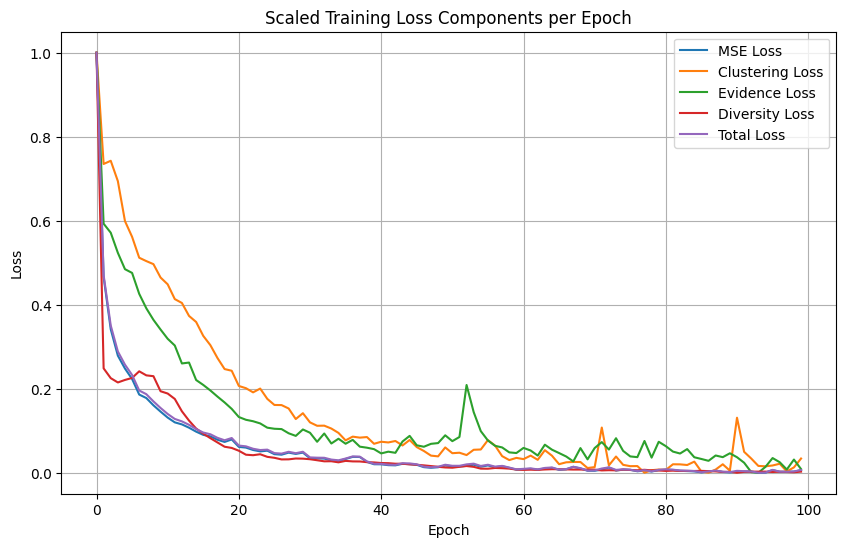

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(scaled_losses[2], label='MSE Loss')
plt.plot(scaled_losses[3], label='Clustering Loss')
plt.plot(scaled_losses[4], label='Evidence Loss')
plt.plot(scaled_losses[5], label='Diversity Loss')
plt.plot(scaled_losses[0], label='Total Loss')

plt.title("Scaled Training Loss Components per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [31]:
from sklearn.manifold import TSNE
def plot_prototypes_and_samples(embeddings, prototypes, method='pca'):
    """
    embeddings: np.array of shape (n_samples, n_features)
    prototypes: np.array of shape (n_prototypes, n_features)
    method: 'pca' or 'tsne'
    """
    assert method in ['pca', 'tsne'], "method must be 'pca' or 'tsne'"

    all_data = np.vstack([embeddings, prototypes])

    if method == 'pca':
        reducer = PCA(n_components=2)
    else:
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)

    reduced = reducer.fit_transform(all_data)
    reduced_samples = reduced[:len(embeddings)]
    reduced_protos = reduced[len(embeddings):]

    # Plot
    plt.figure(figsize=(10, 6))


    plt.scatter(reduced_samples[:, 0], reduced_samples[:, 1], alpha=0.6, label='Samples')

    plt.scatter(reduced_protos[:, 0], reduced_protos[:, 1], color='red', s=200, edgecolors='black', marker='*', label='Prototypes')

    plt.title(f"{method.upper()} Projection of Prototypes and Samples")
    plt.legend()
    plt.grid(True)
    plt.show()


In [35]:
import numpy as np
import torch

def evaluate(model, dataloader, target_scaler, device):
    """
    Evaluate a regression model on the dataloader.

    Args:
        model: PyTorch model
        dataloader: DataLoader with (inputs, targets)
        target_scaler: StandardScaler fitted on training targets
        device: 'cuda' or 'cpu'

    Returns:
        targets_all: np.array of true targets (original scale)
        preds_all: np.array of predicted targets (original scale)
    """
    model.eval()
    preds_all, targets_all = [], []

    with torch.no_grad():
        for inputs, targets in dataloader:
            # Move to device
            inputs, targets = inputs.to(device), targets.to(device)
            print(inputs.shape)
            print(targets.shape)
            # Model prediction
            preds, sims, h = model(inputs)
            print(preds.shape)


            # Convert predictions to CPU numpy and inverse scale
            preds_np = preds.detach().cpu().numpy()
            preds_inv = target_scaler.inverse_transform(preds_np)
            preds_all.append(preds_inv)

            # Convert targets to CPU numpy and inverse scale
            targets_np = targets.detach().cpu().numpy()
            targets_inv = target_scaler.inverse_transform(targets_np)
            targets_all.append(targets_inv)

    # Concatenate all batches
    preds_all = np.concatenate(preds_all)
    targets_all = np.concatenate(targets_all)

    return targets_all, preds_all


In [36]:
targets_all, preds_all  = evaluate(model, test_dl, target_scaler, device)

torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 5])
torch.Size([64, 5])
torch.Size([64, 24, 6])
torch.Size([64, 

In [37]:
import numpy as np

print("\n(Predictions)")
print("  Min:", np.min(preds_all),
      "Max:", np.max(preds_all),
      "Mean:", np.mean(preds_all),
      "Std:", np.std(preds_all))

print("\n(Targets)")
print("  Min:", np.min(targets_all),
      "Max:", np.max(targets_all),
      "Mean:", np.mean(targets_all),
      "Std:", np.std(targets_all))



(Predictions)
  Min: -2.6304684 Max: 44.964302 Mean: 13.341038 Std: 8.506574

(Targets)
  Min: -3.9389997 Max: 45.655 Mean: 13.210439 Std: 8.515823


In [38]:
# Forecast the oil temperature of next 5 time steps (eg : t24,t25,t26,t27,t28)

print("Forecast (next 5 timesteps):", preds_all[0])
print("Ground truth:", targets_all[0])

Forecast (next 5 timesteps): [5.865361  5.638766  5.4639883 5.2080135 5.1213994]
Ground truth: [5.839 5.346 5.909 5.979 5.346]


In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

baseline_pred = np.full_like(y_test, fill_value=np.mean(y_train), dtype=np.float32)

mse_baseline = mean_squared_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline = mean_absolute_error(y_test, baseline_pred)
r2_baseline = r2_score(y_test, baseline_pred)

print("Baseline Performance (Mean Predictor):")
print(f"MSE: {mse_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE: {mae_baseline:.4f}")
print(f"R²: {r2_baseline:.4f}")

mse = mean_squared_error(targets_all, preds_all)
mae = mean_absolute_error(targets_all, preds_all)
rmse = np.sqrt(mse)
r2 = r2_score(targets_all, preds_all)

print("\nModel Performance Metrics):")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Baseline Performance (Mean Predictor):
MSE: 72.5261
RMSE: 8.5162
MAE: 6.7199
R²: -0.0001

Model Performance Metrics):
MSE: 1.5966
RMSE: 1.2636
MAE: 0.9081
R²: 0.9780


In [41]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)  # reference line y=x
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("Predicted vs True")
    plt.show()


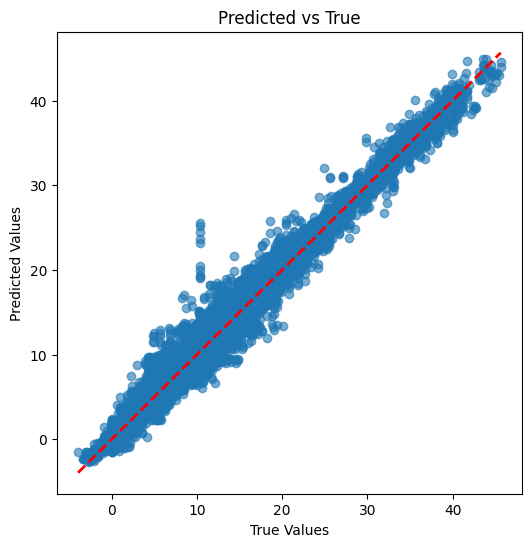

In [42]:
plot_predictions(targets_all, preds_all)

In [43]:
def plot_residuals(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals (True - Pred)")
    plt.title("Residual Plot")
    plt.show()


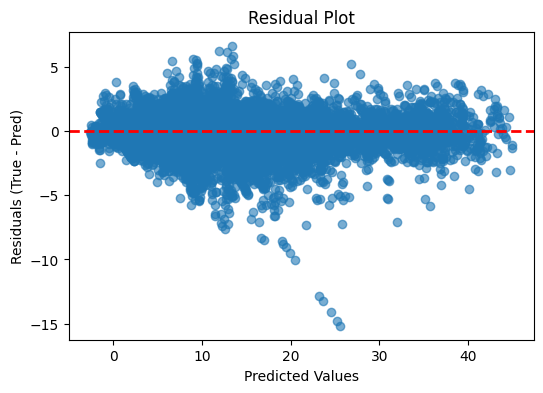

In [44]:
plot_residuals(targets_all, preds_all)

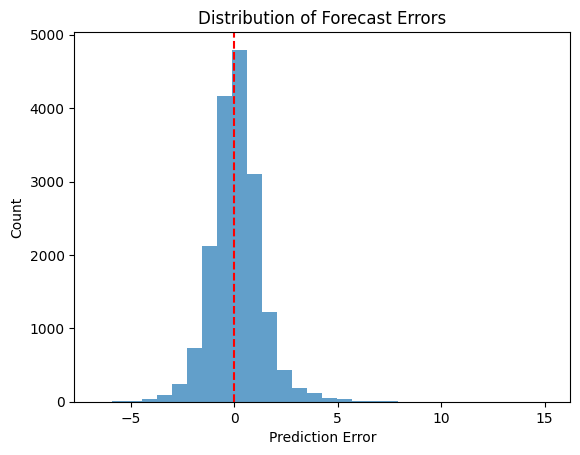

In [45]:
errors = preds_all.flatten() - targets_all.flatten()
plt.hist(errors, bins=30, alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Forecast Errors")
plt.show()


In [46]:
projected_prototypes = project_prototypes(model, train_dl)

print(f"Number of prototypes learned : {len(projected_prototypes)}")
print(projected_prototypes[0].shape)

Number of prototypes learned : 5
torch.Size([24, 6])


In [47]:
# Function to check the scale of prototype features

def check_feature_scales(prototypes):
    """
    Check the min and max values of each feature across all prototypes.

    Args:
        prototypes: list of torch.Tensor of shape [seq_len, num_features]
    """
    all_data = torch.stack(prototypes)  # Shape: [num_prototypes, seq_len, num_features]
    all_data = all_data.view(-1, all_data.shape[-1])  # Shape: [num_prototypes * seq_len, num_features]

    feature_mins = all_data.min(dim=0).values
    feature_maxs = all_data.max(dim=0).values
    feature_ranges = feature_maxs - feature_mins

    for i, (min_val, max_val, rng) in enumerate(zip(feature_mins, feature_maxs, feature_ranges)):
        print(f"Feature {i}: min = {min_val:.3f}, max = {max_val:.3f}, range = {rng:.3f}")


In [48]:
check_feature_scales(projected_prototypes)

Feature 0: min = -2.310, max = 0.890, range = 3.200
Feature 1: min = -2.084, max = 0.878, range = 2.962
Feature 2: min = -2.443, max = 0.806, range = 3.249
Feature 3: min = -2.120, max = 0.935, range = 3.055
Feature 4: min = -1.509, max = 1.114, range = 2.623
Feature 5: min = -0.717, max = 1.165, range = 1.882


In [49]:
import math

def plot_prototypes(prototypes, feature_names):
    """
    Plot each prototype as a multivariate time series in a single window
    with 5 subplots per row.

    Args:
        prototypes: list of torch.Tensor with shape [24, 6]
        feature_names: list of strings of length 6 (names of features)
    """
    num_prototypes = len(prototypes)
    num_cols = 5
    num_rows = math.ceil(num_prototypes / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 3 * num_rows), sharex=True)
    axes = axes.flatten()

    for i, proto in enumerate(prototypes):
        sequence = proto.cpu().numpy()
        ax = axes[i]

        for feat_idx in range(sequence.shape[1]):
            ax.plot(range(sequence.shape[0]), sequence[:, feat_idx], label=feature_names[feat_idx])

        ax.set_title(f"Prototype {i}", fontsize=10)
        ax.set_xlabel("Time Step")
        ax.set_ylabel("Value")
        ax.grid(True)

        if i == 0:
            ax.legend(fontsize=8, loc='upper right')

    # Turn off any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()


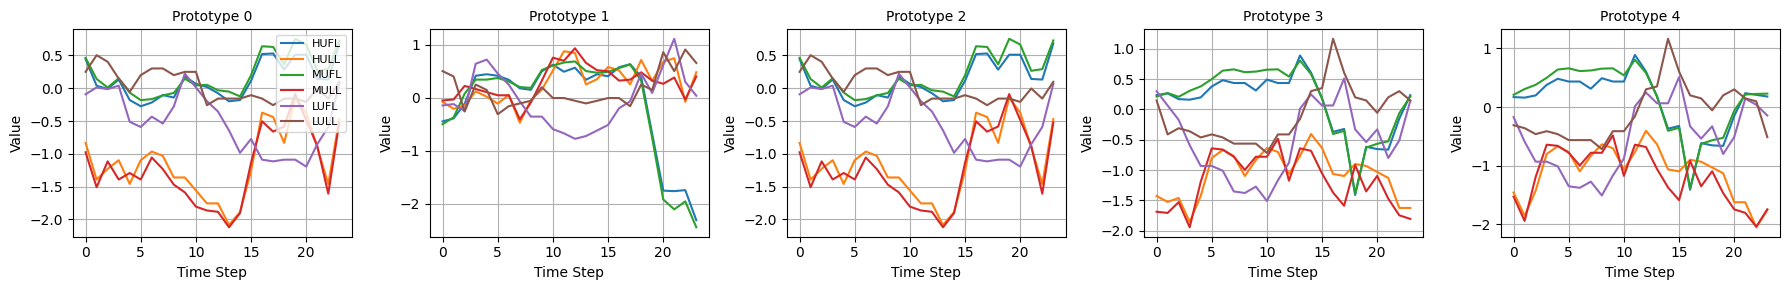

In [50]:
plot_prototypes(projected_prototypes, features)

In [51]:
## Normalize the features of the prototypes to plot all the features in one plot

def normalize_prototypes(prototypes):
    """
    Normalize each feature across all prototypes to [0, 1] range.

    Args:
        prototypes (list of torch.Tensor): Each tensor of shape [seq_len, num_features]

    Returns:
        tuple of torch.Tensor: Normalized tensors with same shape, one per prototype
    """

    # Stack into a tensor: [N, T, F]
    stacked = torch.stack(prototypes)

    # Flatten over time and prototypes: [N*T, F]
    flat = stacked.view(-1, stacked.shape[-1])

    # Feature-wise min/max
    min_vals = flat.min(dim=0).values
    max_vals = flat.max(dim=0).values
    ranges = max_vals - min_vals + 1e-6  # Prevent divide-by-zero

    # Normalize the stacked tensor
    norm_tensor = (stacked - min_vals) / ranges

    # Return as tuple of tensors: each [T, F]
    return tuple(norm_tensor[i] for i in range(norm_tensor.shape[0]))


In [52]:
normalized_prototypes = normalize_prototypes(projected_prototypes)

print(f"Number of prototypes learned : {len(normalized_prototypes)}")
print(normalized_prototypes[0].shape)

Number of prototypes learned : 5
torch.Size([24, 6])


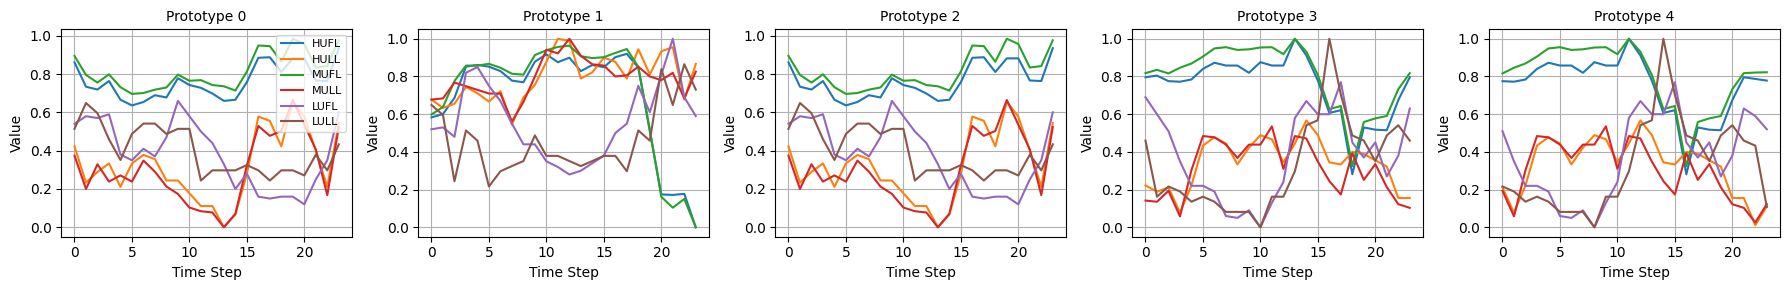

In [53]:
plot_prototypes(normalized_prototypes, features)

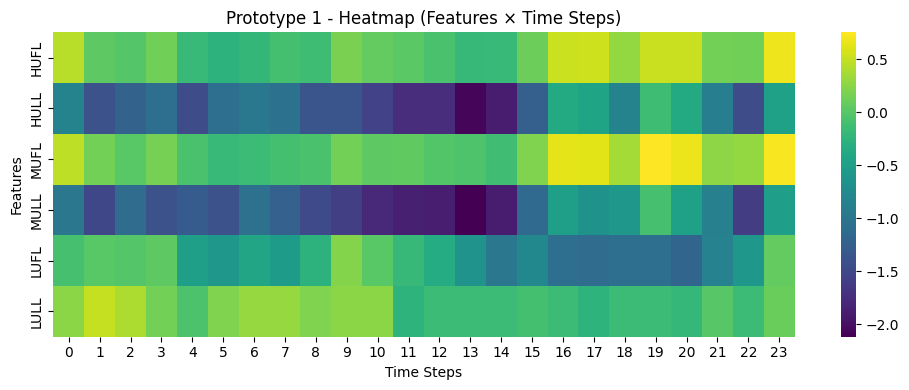

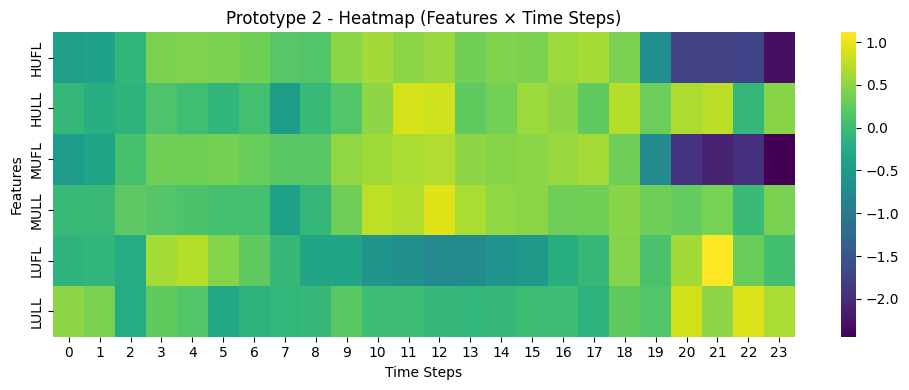

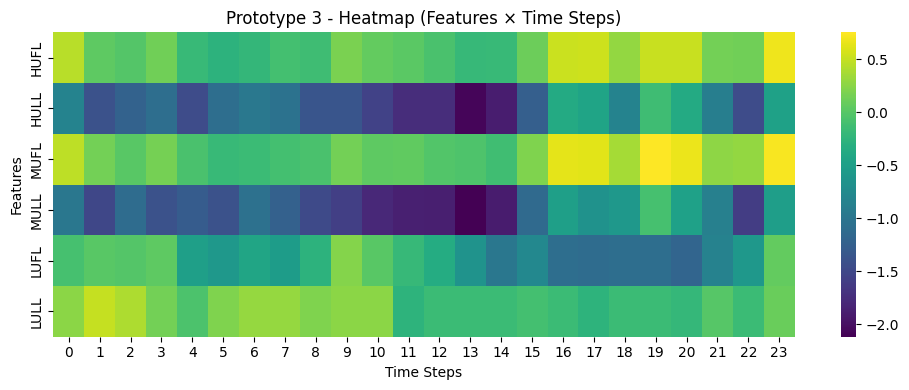

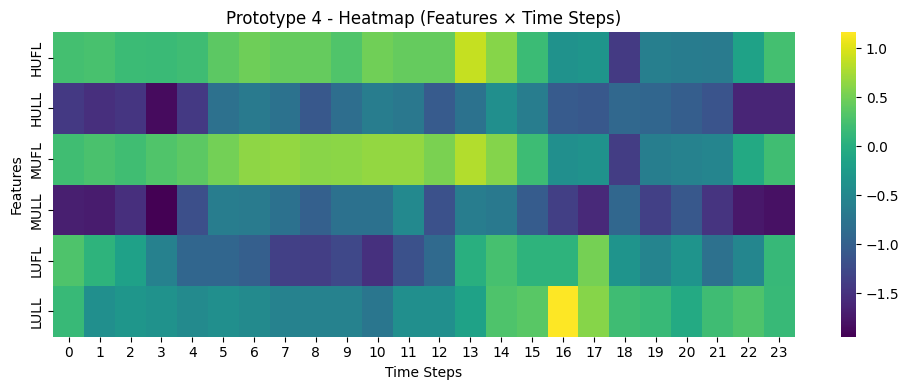

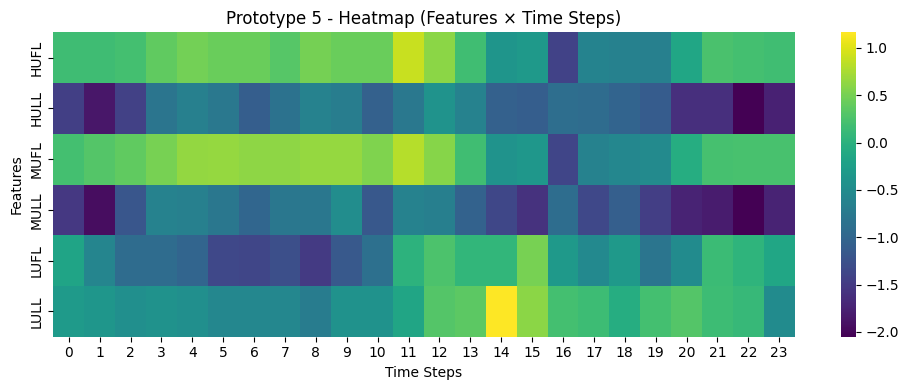

In [54]:
import seaborn as sns

num_prototypes = len(projected_prototypes)

for i in range(num_prototypes):
    prototype = projected_prototypes[i]

    # Convert to numpy if it's a tensor
    if isinstance(prototype, torch.Tensor):
        prototype = prototype.detach().cpu().numpy()

    plt.figure(figsize=(10, 4))
    sns.heatmap(prototype.T, cmap='viridis', cbar=True,
                xticklabels=range(prototype.shape[0]),
                yticklabels=[f"{j}" for j in features])
    plt.title(f"Prototype {i+1} - Heatmap (Features × Time Steps)")
    plt.xlabel("Time Steps")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()


In [55]:
pip install fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567861 sha256=e7ce1eb802fe211cdc0d479871973e6ba0db58367781004e924d4238f539445c
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw


In [56]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

projected_prototypes_np = np.array([p.cpu().numpy() for p in projected_prototypes])

num_protos = projected_prototypes_np.shape[0]
dtw_matrix = np.zeros((num_protos, num_protos))

for i in range(num_protos):
    for j in range(i + 1, num_protos):
        seq_i = projected_prototypes_np[i]  # shape (timesteps, features)
        seq_j = projected_prototypes_np[j]
        dist, _ = fastdtw(seq_i, seq_j, dist=euclidean)
        dtw_matrix[i, j] = dtw_matrix[j, i] = dist


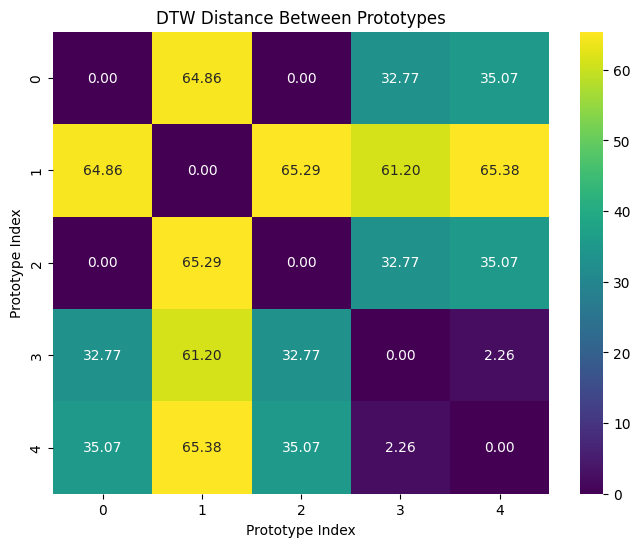

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(dtw_matrix, annot=True, fmt=".2f", cmap='viridis')
plt.title("DTW Distance Between Prototypes")
plt.xlabel("Prototype Index")
plt.ylabel("Prototype Index")
plt.show()

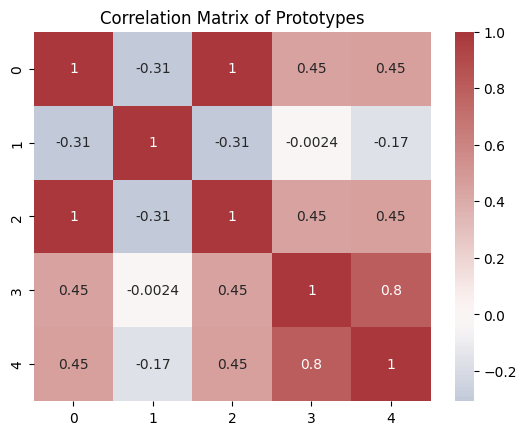

In [58]:
# Flatten each prototype to 1D vector (timesteps * features)
num_protos = projected_prototypes_np.shape[0]
flattened_protos = projected_prototypes_np.reshape(num_protos, -1)  # shape: (num_protos, timesteps*features)

# Compute correlation matrix between prototypes
corr_matrix = np.corrcoef(flattened_protos)

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0)
plt.title("Correlation Matrix of Prototypes")
plt.show()



In [59]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from collections import defaultdict

def hierarchical_clustering_medoids(dtw_matrix, threshold):
    """
    Perform Hierarchical Clustering using DTW distance matrix
    and return medoids for each cluster.

    Args:
        dtw_matrix (np.array): Square DTW distance matrix [NxN]
        threshold (float): Distance threshold to cut dendrogram

    Returns:
        cluster_labels (np.array): Cluster assignment per prototype
        medoids (dict): {cluster_id: medoid_prototype_index}
    """
    # Convert to condensed form
    dtw_condensed = squareform(dtw_matrix)

    # Perform Hierarchical Clustering
    linkage_matrix = linkage(dtw_condensed, method='average')

    # Get Cluster Assignments
    cluster_labels = fcluster(linkage_matrix, t=threshold, criterion='distance')

    # Find Medoids in each cluster
    clusters = defaultdict(list)
    for idx, label in enumerate(cluster_labels):
        clusters[label].append(idx)

    medoids = {}
    for label, indices in clusters.items():
        min_sum_distance = float('inf')
        medoid_idx = None

        for i in indices:
            sum_distance = sum(dtw_matrix[i, j] for j in indices if i != j)
            if sum_distance < min_sum_distance:
                min_sum_distance = sum_distance
                medoid_idx = i

        medoids[label] = medoid_idx

    return cluster_labels, medoids

# --- Usage ---
threshold = 20  # You can adjust this threshold
cluster_labels, medoids = hierarchical_clustering_medoids(dtw_matrix, threshold)

print(f"Cluster Assignments: {cluster_labels}")
print(f"Cluster Medoids: {medoids}")


Cluster Assignments: [1 3 1 2 2]
Cluster Medoids: {np.int32(1): 0, np.int32(3): 1, np.int32(2): 3}


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

def plot_dendrogram_with_medoids(dtw_matrix, cluster_labels, medoids, threshold=None):
    # Convert to condensed form
    dtw_condensed = squareform(dtw_matrix)

    # Compute linkage matrix
    linkage_matrix = linkage(dtw_condensed, method='average')

    plt.figure(figsize=(12, 6))
    dendro = dendrogram(linkage_matrix, labels=[f"P{i}" for i in range(dtw_matrix.shape[0])],
                        color_threshold=threshold, above_threshold_color='gray')
    plt.title("Hierarchical Clustering Dendrogram (DTW Distance)")
    plt.xlabel("Prototypes")
    plt.ylabel("DTW Distance")

    # Highlight medoids on x-axis labels
    ax = plt.gca()
    xlbls = ax.get_xmajorticklabels()
    medoid_indices = list(medoids.values())
    for lbl in xlbls:
        proto_idx = int(lbl.get_text().replace('P', ''))
        if proto_idx in medoid_indices:
            lbl.set_color('red')
            lbl.set_fontweight('bold')

    plt.show()


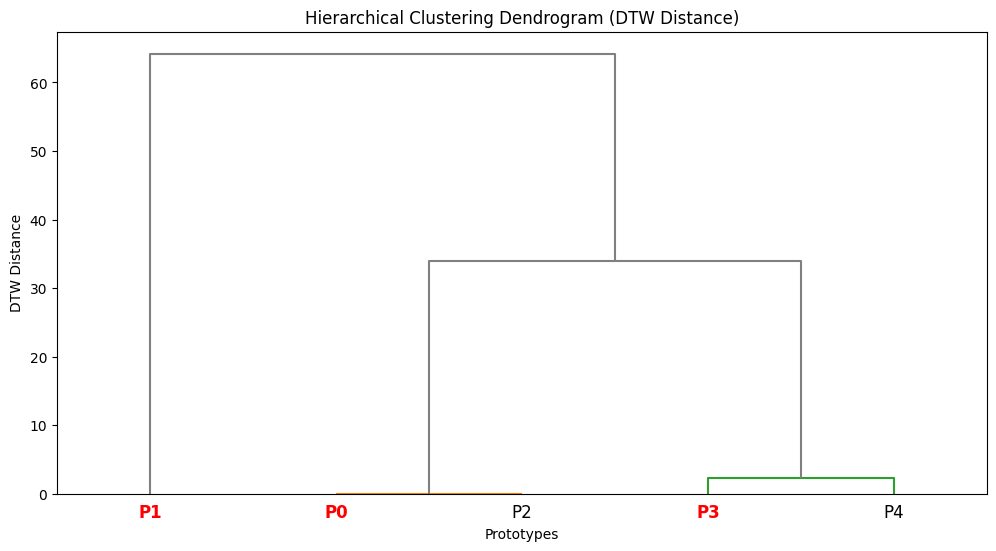

In [61]:
threshold = 20  # Adjust based on your desired cut-off
plot_dendrogram_with_medoids(dtw_matrix, cluster_labels, medoids, threshold=threshold)

In [62]:
from itertools import combinations

projected_prototypes = torch.stack([
p.float() if isinstance(p, torch.Tensor) else torch.tensor(p, dtype=torch.float32)
for p in projected_prototypes])

flat_prototypes = projected_prototypes.view(projected_prototypes.size(0), -1).cpu().detach().numpy()  # [10, 144]

# kmeans = KMeans(n_clusters=3, random_state=0)
# cluster_labels = kmeans.fit_predict(flat_prototypes)  # Shape: [10]
# cluster_centers = kmeans.cluster_centers_

print(f"#Prototypes: {n_prototypes} \n")

intra_distances, inter_distances = compute_intra_inter_distances(dtw_matrix, cluster_labels, medoids)

print("Intra-cluster Distances:")
for cluster_id, dist in sorted(intra_distances.items()):
    print(f"Cluster {cluster_id}: {dist:.2f}")

print("\nInter-cluster Distances between Medoids:")
for (c1, c2), dist in sorted(inter_distances.items()):
    print(f"Cluster {c1} to Cluster {c2}: {dist:.2f}")

#Prototypes: 5 

Intra-cluster Distances:
Cluster 1: 0.00
Cluster 2: 2.26
Cluster 3: 0.00

Inter-cluster Distances between Medoids:
Cluster 1 to Cluster 2: 32.77
Cluster 1 to Cluster 3: 64.86
Cluster 3 to Cluster 2: 61.20


In [63]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from collections import defaultdict

def prune_prototypes_by_dtw(dtw_matrix, threshold):
    """
    Prune redundant prototypes using Hierarchical Clustering on DTW distance.

    Args:
        dtw_matrix (np.array): Square DTW distance matrix [NxN]
        threshold (float): DTW distance threshold for pruning

    Returns:
        distinct_prototypes (list): Indices of distinct prototypes (medoids)
        pruned_prototypes (list): Indices of pruned (redundant) prototypes
        cluster_labels (np.array): Cluster label for each prototype
    """
    # Convert DTW matrix to condensed form
    dtw_condensed = squareform(dtw_matrix)

    # Hierarchical Clustering
    linkage_matrix = linkage(dtw_condensed, method='average')

    # Cut tree at threshold
    cluster_labels = fcluster(linkage_matrix, t=threshold, criterion='distance')

    # Find Medoids (most central prototype per cluster)
    clusters = defaultdict(list)
    for idx, label in enumerate(cluster_labels):
#         print(f"Cluster {label} members: {idx}")
        clusters[label].append(idx)

    distinct_prototypes = []
    pruned_prototypes = []



    for label, indices in clusters.items():
        print(f"Cluster {label} members: {indices}")
        print(len(indices))

        if len(indices) == 1:
            medoid_idx = indices[0]
            distinct_prototypes.append(medoid_idx)
            continue

        # For clusters with multiple members:
        min_sum_distance = float('inf')
        medoid_idx = None

        for i in indices:
            sum_distance = sum(dtw_matrix[i, j] for j in indices if i != j)
            if sum_distance < min_sum_distance:
                min_sum_distance = sum_distance
                medoid_idx = i

        distinct_prototypes.append(medoid_idx)


        # Others are pruned
        pruned = [i for i in indices if i != medoid_idx]
        pruned_prototypes.extend(pruned)

    return distinct_prototypes, pruned_prototypes, cluster_labels



In [64]:
threshold = 20  # Set threshold based on dendrogram observation
distinct_prototypes, pruned_prototypes, cluster_labels = prune_prototypes_by_dtw(dtw_matrix, threshold)

print(f"Distinct Prototypes (Medoids): {distinct_prototypes}")
print(f"Pruned (Redundant) Prototypes: {pruned_prototypes}")

Cluster 1 members: [0, 2]
2
Cluster 3 members: [1]
1
Cluster 2 members: [3, 4]
2
Distinct Prototypes (Medoids): [0, 1, 3]
Pruned (Redundant) Prototypes: [2, 4]


In [65]:
def update_prosenet_with_pruned_prototypes(model, retained_proto_indices):
    """
    Updates the ProSeNet model after prototype pruning.

    Args:
        model (nn.Module): The original ProSeNet model.
        retained_proto_indices (list): List of prototype indices to keep (medoids after pruning).

    Returns:
        updated_model (nn.Module): A new ProSeNet model with updated prototypes and fc layer.
    """
    device = model.device
    retained_proto_indices = sorted(retained_proto_indices)

    # Extract pruned prototypes
    new_prototypes = model.prototypes[retained_proto_indices].detach().clone()
    new_num_prototypes = new_prototypes.shape[0]
    old_num_prototypes = model.prototypes.shape[0]

    print(f"Updating model: Retaining {new_num_prototypes} out of {old_num_prototypes} prototypes.")

#     # Update the fc (classification) layer to match new prototype count
#     old_fc_weights = model.fc.weight.data[:, retained_proto_indices].detach().clone()
#     old_fc_bias = model.fc.bias.data.detach().clone()

#     # Re-create the fc layer
#     model.fc = nn.Linear(new_num_prototypes, model.fc.out_features)
#     model.fc.weight.data = old_fc_weights.to(device)
#     model.fc.bias.data = old_fc_bias.to(device)

    # Replace model's prototypes with pruned prototypes
    model.prototypes = nn.Parameter(new_prototypes.to(device))

    return model


In [66]:
retained_proto_indices = distinct_prototypes  # The medoids you kept after pruning
updt_model = update_prosenet_with_pruned_prototypes(model, retained_proto_indices)

Updating model: Retaining 3 out of 5 prototypes.


In [67]:
updt_model

ProSeNetRegressor(
  (encoder): LSTM(6, 64, num_layers=3, batch_first=True, dropout=0.1, bidirectional=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)

In [68]:
def count_prototype_utilization(model, dataloader, device='cpu'):
    model.eval()
    prototype_counts = torch.zeros(model.prototypes.shape[0], dtype=torch.int32)

    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)
            _, sims, _ = model(inputs)
            assigned_proto = torch.argmax(sims, dim=1)  # Assigned prototype per sample

            for idx in assigned_proto:
                prototype_counts[idx.item()] += 1

    return prototype_counts


In [69]:
prototype_counts = count_prototype_utilization(updt_model, train_dl)

Prototype utilization summary:
Prototype 0: assigned 6489 samples
Prototype 1: assigned 1698 samples
Prototype 2: assigned 2943 samples


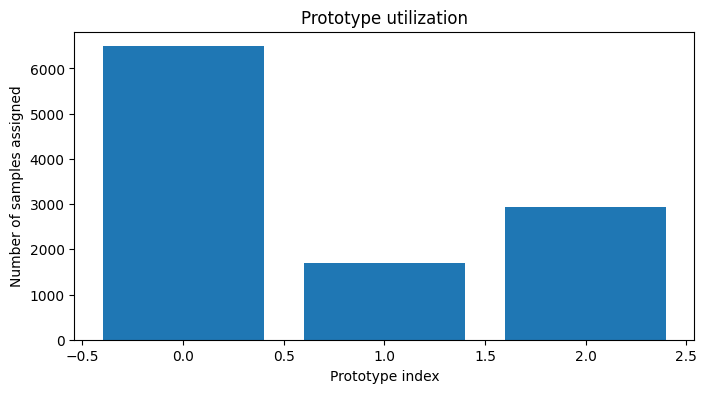

In [70]:

print("Prototype utilization summary:")
for i, count in enumerate(prototype_counts):
    print(f"Prototype {i}: assigned {count} samples")

# Optional: visualize
plt.figure(figsize=(8, 4))
plt.bar(range(len(prototype_counts)), prototype_counts)
plt.xlabel("Prototype index")
plt.ylabel("Number of samples assigned")
plt.title("Prototype utilization")
plt.show()




In [71]:
latest_protos = updt_model.prototypes
print(latest_protos.shape)

torch.Size([3, 128])


In [72]:
latest_protos = project_prototypes(updt_model, train_dl)
print(len(latest_protos))

3


In [73]:
import numpy as np
from scipy.fft import rfft

def analyze_feature_shape(signal, freq_threshold=0.1, step_threshold=0.3, flat_threshold=0.05):
    """
    Classifies a 1D time series signal based on shape and frequency properties.

    Parameters:
        signal (np.ndarray): 1D array of time series values (e.g., one feature from a prototype).
        freq_threshold (float): threshold ratio for detecting high-frequency content.
        step_threshold (float): threshold for detecting a sudden step change.
        flat_threshold (float): threshold for detecting flat signal variation.

    Returns:
        str: one of ["flat", "step", "oscillating", "trending"]
    """
    signal = np.asarray(signal)
    diffs = np.diff(signal)
    max_jump = np.max(np.abs(diffs))
    total_variation = np.sum(np.abs(diffs))

    # 1. Check flatness
    if np.std(signal) < flat_threshold:
        return "flat"

    # 2. Check for step change
    if max_jump > step_threshold:
        return "step"

    # 3. Check oscillation using FFT
    fft_vals = np.abs(rfft(signal - np.mean(signal)))
    if len(fft_vals) < 2:
        return "flat"  # Not enough signal to analyze
    dominant_freq_ratio = np.max(fft_vals[1:]) / (np.sum(fft_vals[1:]) + 1e-8)
    if dominant_freq_ratio > freq_threshold:
        return "oscillating"

    # 4. Otherwise, it's a trend
    return "trending"


In [74]:
def analyze_prototypes_shape(prototypes, features,
                              freq_threshold=0.1, step_threshold=0.5, flat_threshold=0.05):
    """
    Applies shape classification to each feature in each prototype.

    Parameters:
        prototypes (np.ndarray): shape (num_prototypes, seq_len, num_features)
        feature_names (list of str): names of each feature (length = num_features)
        freq_threshold (float): threshold for oscillation detection
        step_threshold (float): threshold for step change detection
        flat_threshold (float): threshold for flat signal detection

    Returns:
        dict: Nested dictionary with structure:
              {prototype_index: {feature_name: shape_label}}
    """
    results = {}
    projected_prototypes_tensor = torch.stack(prototypes)
    prototypes = projected_prototypes_tensor.cpu().detach().numpy()
#     prototypes = prototypes.detach().cpu().numpy()
    for p_idx, proto in enumerate(prototypes):
        feature_shapes = {}
        for f_idx, fname in enumerate(features):
            shape_label = analyze_feature_shape(proto[:, f_idx],
                                                freq_threshold=freq_threshold,
                                                step_threshold=step_threshold,
                                                flat_threshold=flat_threshold)
            feature_shapes[fname] = shape_label
        results[p_idx] = feature_shapes
    return results


In [75]:
analyze_prototypes_shape(latest_protos, features)

{0: {'HUFL': 'step',
  'HULL': 'step',
  'MUFL': 'oscillating',
  'MULL': 'step',
  'LUFL': 'step',
  'LULL': 'step'},
 1: {'HUFL': 'step',
  'HULL': 'step',
  'MUFL': 'step',
  'MULL': 'oscillating',
  'LUFL': 'step',
  'LULL': 'step'},
 2: {'HUFL': 'step',
  'HULL': 'step',
  'MUFL': 'step',
  'MULL': 'step',
  'LUFL': 'step',
  'LULL': 'step'}}

In [76]:
import random

# Get one random batch first
inputs, target = random.choice(list(test_dl))

# Select one random item from the batch
idx = random.randint(0, inputs.size(0) - 1)
sample_input = inputs[idx].unsqueeze(0)
sample_target = target[idx].unsqueeze(0)
print(sample_input.shape)
print(sample_target.shape)


torch.Size([1, 24, 6])
torch.Size([1, 5])


# How to find the closest prototype for a particular prediction

In [77]:
# Put model in evaluation mode
model.eval()

with torch.no_grad():
    # Move sample to device
    sample_input = sample_input.to(device)

    # Model prediction
    preds, sims, h = updt_model(sample_input)   # preds = [1, horizon], sims = [1, num_prototypes]

    topk = 1
    topk_sim_values, topk_proto_indices = torch.topk(sims, k=topk, largest=True)

    # Forecasted next 5 steps
    forecast = preds.squeeze().cpu().numpy()
    print("Forecast (next 5 steps):", forecast)

    # Find closest prototype
    sims = sims.squeeze(0).cpu().numpy()   # shape [num_prototypes]

    closest_proto_idx = sims.argmax()
    print("Closest prototype index:", closest_proto_idx)

    # Retrieve prototype vector
    # closest_proto = updt_model.prototypes[closest_proto_idx]
    closest_proto = latest_protos[closest_proto_idx]

    print(closest_proto.shape)




Forecast (next 5 steps): [0.84891635 0.80001485 0.7466339  0.692102   0.6455232 ]
Closest prototype index: 0
torch.Size([24, 6])


In [78]:
print(f"Top {topk} closest prototypes based on similarity:")

for i, proto_idx in enumerate(topk_proto_indices[0]):
    idx = proto_idx.item()  # convert tensor to int
    proto_input = latest_protos[idx].unsqueeze(0).to(device)

    print(f"{i+1}. Prototype #{proto_idx.item()} | Similarity: {topk_sim_values[0][i].item():.4f}")

Top 1 closest prototypes based on similarity:
1. Prototype #0 | Similarity: 0.0000


In [81]:
!pip install transformers accelerate torch

In [89]:
!pip install -U langchain-community

In [90]:
with open("/content/drive/MyDrive/Documents/data_summary.txt", 'w') as f:
    f.write("""The ETT dataset contains time series data from electricity transformers.
It includes the target variable 'OT' (Oil Temperature) and 6 features:
HUFL, HULL, MUFL, MULL, LUFL, LULL — each representing power load patterns at different levels.
OT exhibits seasonal trends and local continuity, while load features show daily and weekly periodic patterns.""")

with open("/content/drive/MyDrive/Documents/model_summary.txt", 'w') as f:
    f.write("""Prosenet model is a sequence to perform time series Forecasting. It consist of 3 layers : encoder, prototypes and
output layer. Encoder is deep learning model such as LSTM or GRU. Prototype layer learns the prototypes which are exemplar cases in
the problem domain. Output layer return the Oil temperature for the next 5 time steps of the new input sequence with its  similarities with each representative
sequences are measured in the learned latent space. Then, the prediction of the new instance can be derived and explained by its
similar prototype sequences.""")

with open("/content/drive/MyDrive/Documents/prototype_summary.txt", 'w') as f:
    f.write("""Prototypes are the exemplar or representative sequences in the problem domain which are not necessarily exist in the
training data. We leverage the concept of prototype learning to construct deep sequence model with built-in interpretability.
Prototype learning is a form of case-based reasoning, which draws conclusions for new inputs by comparing them with a few exemplar
cases(ie, prototypes) in the problem domain.""")


In [91]:
summary_dict = analyze_prototypes_shape(
    prototypes=latest_protos,
    features=features
)

print(summary_dict)

{0: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'oscillating', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'step'}, 1: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'step', 'MULL': 'oscillating', 'LUFL': 'step', 'LULL': 'step'}, 2: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'step', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'step'}}


In [92]:
def build_iteration_summary_text(summary_dict):
    text = "Prototype Feature Pattern Summary:\n\n"
    for proto_id, features in summary_dict.items():
        text += f"Prototype {proto_id}:\n"
        for feature, pattern in features.items():
            text += f"  - {feature}: {pattern}\n"
        text += "\n"
    return text

iteration_summary_text = build_iteration_summary_text(summary_dict)


In [93]:
with open("/content/drive/MyDrive/Documents/iteration_summary.txt", "w") as f:
    f.write(iteration_summary_text)


In [100]:
!pip install langchain-text-splitters


In [95]:
!pip install langchain langchain-community


In [99]:
import langchain
print(langchain.__version__)


1.1.0


In [103]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_paths = [
    "/content/drive/MyDrive/Documents/data_summary.txt",
    "/content/drive/MyDrive/Documents/model_summary.txt",
    "/content/drive/MyDrive/Documents/prototype_summary.txt",
    "/content/drive/MyDrive/Documents/iteration_summary.txt",
]


documents = []
for path in text_paths:
    loader = TextLoader(path, encoding="utf-8")
    documents.extend(loader.load())

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

docs = splitter.split_documents(documents)

print(f"Loaded {len(documents)} raw docs")
print(f"Split into {len(docs)} chunks")


Loaded 4 raw docs
Split into 4 chunks


In [104]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.9 MB/s 

In [106]:
!pip install langchain-chroma langchain-huggingface


In [109]:

# from langchain_chroma import Chroma
# from langchain_huggingface import HuggingFaceEmbeddings


# #from langchain.embeddings import HuggingFaceEmbeddings  # optional if using local

# embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# vectorstore = Chroma.from_documents(
#     documents=documents,
#     embedding=embedding,
#     persist_directory="./chroma_rag_ett"
# )

# vectorstore.persist()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

AttributeError: 'Chroma' object has no attribute 'persist'

In [110]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

# Create embeddings
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# Create / persist vectorstore
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding,
    persist_directory="./chroma_rag_ett"  # automatically persists
)

print("✅ Vector store created and saved to ./chroma_rag_ett")


✅ Vector store created and saved to ./chroma_rag_ett


In [111]:
retriever = vectorstore.as_retriever(search_type="similarity", k=3)

In [112]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

llm_model_name = "HuggingFaceTB/SmolLM2-1.7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(llm_model_name)
llm_model = AutoModelForCausalLM.from_pretrained(
    llm_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.42G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [113]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=tokenizer,
    torch_dtype=torch.float16,
    device_map="auto"
)


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


In [114]:
# query the retriever
query = (
    f"Give a short explanation of the ProSeNet model's forecast. "
    f"The model predicted oil temperature for the next 5 time steps as {forecast}. "
    f"Explain briefly how these values are influenced by the input sequence {sample_seq}, "
    f"and its closest prototype {nearest_proto} with similarity score {topk_sim_values[0][0].item():.4f}. "
    f"Keep the explanation concise and script-like."
)

#query = "Why did the model match this input with prototype X?"
retrieved_docs = retriever.invoke(query)

# Join retrieved context into a string
retrieved_context = "\n".join([doc.page_content for doc in retrieved_docs])


In [116]:
prompt = f"""
### Task:
You are an expert in time series forecasting and prototype-based explainability.

The prototype based model (Prosenet) model has made the forecasting as follows using the Electricity Transformer data. It explains decisions using
learned prototypes derived from patterns in historical transformer load features.

### Context (retrieved facts about prototypes and features):
{retrieved_context}

### Prediction Summary:
-
- Nearest Prototype Index: {closest_proto_idx}
- Prototype Distance: {topk_sim_values[0][0].item():.4f}

### Instruction:
Generate a concise and **feature-based** explanation for why the model predicted these values.

**Requirements:**
- Mention each of the following input features: `HUFL`, `HULL`, `MUFL`, `MULL`, `LUFL`, and `LULL`.
- Describe how each of these features compares or contributes to the match with the prototype.
- Clearly state how these features align with the prototype and led to the prediction.
- Use short, clear, human-like sentences suitable for a technical report.
- Avoid vague generalities (e.g. "input aligns with prototype") — be **specific about feature values or trends**.

### Answer:
"""


In [117]:

# output = generator(
#     prompt,
#     max_new_tokens=300,
#     do_sample=True,
#     temperature=0.7,
#     return_full_text=False
# )[0]["generated_text"]

# print("📘 Final Explanation:\n")
# print(output.strip())


# Path to save all explanations
output_path = "/content/drive/MyDrive/Documents/explanations.txt"

# Generate explanation
output = generator(
    prompt,
    max_new_tokens=300,
    do_sample=True,
    temperature=0.7,
    return_full_text=False
)[0]["generated_text"]

final_text = output.strip()

# Print to screen
print("📘 Final Explanation:\n")
print(final_text)

# --- Append to file ---
with open(output_path, "a") as f:
    f.write(final_text + "\n")


📘 Final Explanation:

The `HUFL` feature is much lower than other features, indicating that the input data is mostly composed of short load segments. The model predicts `OT` to be around 25, which is in the middle of the monthly average.

The `MUFL` feature is higher than the `HUFL` feature but significantly lower than `LUFL` and `LULL`. This suggests that the input data contains a mix of longer load segments and shorter segments with moderate loading. The model predicts `OT` to be around 30, which is higher than the average monthly temperature.

The `LUFL` and `LULL` features are both higher than `HUFL` and `MUFL`. The model predicts `OT` to be around 35, which is even higher than the average monthly temperature.

The `HULL` feature is higher than `MUFL` but lower than `LUFL` and `LULL`. This suggests that the input data has a mix of longer load segments and segments with moderate loading, similar to what was seen in the previous features. The model predicts `OT` to be around 40, whic

In [118]:
def explanation_metrics(explanation, expected_features):
    words = explanation.split()
    length = len(words)

    completeness = sum(1 for f in expected_features if f in explanation)
    completeness_score = 0
    if completeness == 0:
        completeness_score = 0
    elif completeness < len(expected_features):
        completeness_score = 1
    else:
        completeness_score = 2

    return {
        "length": length,
        "completeness": completeness_score
    }

# # Define your features
# features = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]

# # Generate explanation
# output = generator(
#     prompt,
#     max_new_tokens=200,
#     do_sample=True,
#     temperature=0.7,
#     return_full_text=False
# )[0]["generated_text"]

# # Print and evaluate
print("📝 Generated Explanation:\n", output.strip())

metrics = explanation_metrics(output, features)
print("\n📊 Evaluation Metrics:")
for key, val in metrics.items():
    print(f"- {key}: {val}")


📝 Generated Explanation:
 The `HUFL` feature is much lower than other features, indicating that the input data is mostly composed of short load segments. The model predicts `OT` to be around 25, which is in the middle of the monthly average.

The `MUFL` feature is higher than the `HUFL` feature but significantly lower than `LUFL` and `LULL`. This suggests that the input data contains a mix of longer load segments and shorter segments with moderate loading. The model predicts `OT` to be around 30, which is higher than the average monthly temperature.

The `LUFL` and `LULL` features are both higher than `HUFL` and `MUFL`. The model predicts `OT` to be around 35, which is even higher than the average monthly temperature.

The `HULL` feature is higher than `MUFL` but lower than `LUFL` and `LULL`. This suggests that the input data has a mix of longer load segments and segments with moderate loading, similar to what was seen in the previous features. The model predicts `OT` to be around 40, 

In [119]:
# ⚠️ This replaces Java 11 with Java 17
!sudo apt-get update -y
!sudo apt-get install openjdk-17-jdk -y

# Make Java 17 default
!sudo update-alternatives --install /usr/bin/java java /usr/lib/jvm/java-17-openjdk-amd64/bin/java 1
!sudo update-alternatives --set java /usr/lib/jvm/java-17-openjdk-amd64/bin/java

# Check version
!java -version


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,196 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,508 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/m

In [120]:
!pip install -q language-tool-python textstat


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.4 MB/s eta 0:00:00


In [121]:
import language_tool_python
import textstat

def explanation_metrics_full(explanation, expected_features):
    # Length (word count)
    words = explanation.split()
    length = len(words)

    # Completeness
    completeness = sum(1 for f in expected_features if f in explanation)
    if completeness == 0:
        completeness_score = 0
    elif completeness < len(expected_features):
        completeness_score = 1
    else:
        completeness_score = 2

    # Fluency (grammar errors using LanguageTool)
    tool = language_tool_python.LanguageTool('en-US')
    matches = tool.check(explanation)
    fluency_errors = len(matches)

    # Readability (Flesch Reading Ease, higher = easier to read)
    readability = textstat.flesch_reading_ease(explanation)

    return {
        "length": length,
        "completeness_score (0–2)": completeness_score,
        "fluency_grammar_errors (↓ better)": fluency_errors,
        "readability_score (↑ better)": readability
    }


In [122]:
metrics = explanation_metrics_full(output, features)
for key, value in metrics.items():
    print(f"{key}: {value}")

length: 205
completeness_score (0–2): 2
fluency_grammar_errors (↓ better): 11
readability_score (↑ better): 60.73834349593497


In [123]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.cluster import KMeans


# class ProSeNetRegressorWithText(nn.Module):
#     def __init__(self, input_dim, text_dim, hidden_dim, num_prototypes, train_loader, horizon,
#                  dropout_prob=0.2, device='cpu'):
#         super(ProSeNetRegressorWithText, self).__init__()
#         self.device = device

#         # ---- Time-series encoder ----
#         self.encoder = nn.LSTM(
#             input_dim, hidden_dim, num_layers=3,
#             batch_first=True, bidirectional=True, dropout=dropout_prob
#         )
#         self.dropout = nn.Dropout(dropout_prob)

#         # ---- Text projection ----
#         # You will use frozen embeddings from a text model (e.g., MiniLM)
#         self.text_proj = nn.Linear(text_dim, hidden_dim * 2)

#         # ---- Fusion layer ----
#         # Fuse time & text into shared latent space
#         self.fusion_layer = nn.Linear(hidden_dim * 4, hidden_dim * 2)
#         self.fusion_norm = nn.LayerNorm(hidden_dim * 2)

#         # ---- Regression head ----
#         self.fc = nn.Linear(num_prototypes, horizon)

#         # ---- Initialize prototypes ----
#         self.prototypes = nn.Parameter(
#             self.kmeans_init(train_loader, num_prototypes, hidden_dim)
#         )

#         self.to(self.device)

#     def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
#         """Initialize prototypes using only the time-series embeddings."""
#         all_embeddings = []
#         self.eval()
#         with torch.no_grad():
#             for batch in train_loader:
#                 # Handle both (data, target) and (data, target, text_emb)
#                 if len(batch) == 3:
#                     data, _, _ = batch
#                 elif len(batch) == 2:
#                     data, _ = batch
#                 else:
#                     raise ValueError("Unexpected number of items in train_loader batch.")

#                 data = data.to(self.device)
#                 _, (h_n, _) = self.encoder(data)
#                 h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#                 all_embeddings.append(h.cpu().numpy())

#         all_embeddings = np.vstack(all_embeddings)
#         kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
#         kmeans.fit(all_embeddings)
#         prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
#         return prototypes

#     def forward(self, x, text_emb):
#         """
#         x: [B, T, input_dim]  -- time-series data
#         text_emb: [B, text_dim]  -- encoded explanation embeddings (e.g., MiniLM)
#         """
#         x = x.to(self.device)
#         text_emb = text_emb.to(self.device)

#         # --- Time-series encoding ---
#         _, (h_n, _) = self.encoder(x)
#         h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#         h = self.dropout(h)

#         # --- Text projection & fusion ---
#         t = torch.relu(self.text_proj(text_emb))  # [B, hidden_dim*2]
#         fused = torch.cat([h, t], dim=1)          # [B, hidden_dim*4]
#         fused = torch.relu(self.fusion_layer(fused))
#         fused = self.fusion_norm(fused)

#         # --- Prototype similarity ---
#         dists = torch.cdist(fused, self.prototypes, p=2)
#         sims = torch.exp(-dists ** 2)

#         # --- Regression output ---
#         out = self.fc(sims)
#         return out.squeeze(-1), sims, fused


In [124]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.cluster import KMeans

# class ProSeNetRegressorWithText(nn.Module):
#     def __init__(self, input_dim, text_dim, hidden_dim, num_prototypes, train_loader, horizon,
#                  dropout_prob=0.2, device='cpu'):
#         super(ProSeNetRegressorWithText, self).__init__()
#         self.device = device

#         # ---- Time-series encoder ----
#         self.encoder = nn.LSTM(
#             input_dim, hidden_dim, num_layers=3,
#             batch_first=True, bidirectional=True, dropout=dropout_prob
#         )
#         self.dropout = nn.Dropout(dropout_prob)

#         # ---- Text projection ----
#         self.text_proj = nn.Linear(text_dim, hidden_dim * 2)

#         # ---- Fusion layer ----
#         self.fusion_layer = nn.Linear(hidden_dim * 4, hidden_dim * 2)
#         self.fusion_norm = nn.LayerNorm(hidden_dim * 2)

#         # ---- Regression head ----
#         self.fc = nn.Linear(num_prototypes, horizon)

#         # ✅ Move model to device BEFORE k-means init
#         self.to(self.device)

#         # ---- Initialize prototypes ----
#         prototypes = self.kmeans_init(train_loader, num_prototypes, hidden_dim)
#         self.prototypes = nn.Parameter(prototypes.to(self.device))

#     def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
#         """Initialize prototypes using only the time-series embeddings."""
#         all_embeddings = []
#         self.eval()
#         with torch.no_grad():
#             for batch in train_loader:
#                 # Support both (data, target) and (data, target, text_emb)
#                 if len(batch) == 3:
#                     data, _, _ = batch
#                 elif len(batch) == 2:
#                     data, _ = batch
#                 else:
#                     raise ValueError("Unexpected number of items in train_loader batch.")

#                 data = data.to(self.device)
#                 _, (h_n, _) = self.encoder(data)     # Encoder now on GPU ✅
#                 h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#                 all_embeddings.append(h.cpu().numpy())    # Move back to CPU for KMeans

#         all_embeddings = np.vstack(all_embeddings)
#         kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
#         kmeans.fit(all_embeddings)

#         prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
#         return prototypes

#     def forward(self, x, text_emb):
#         # Ensure inputs are on the same device
#         x = x.to(self.device)
#         text_emb = text_emb.to(self.device)

#         # --- Time-series encoding ---
#         _, (h_n, _) = self.encoder(x)
#         h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#         h = self.dropout(h)

#         # --- Text projection & fusion ---
#         t = torch.relu(self.text_proj(text_emb))  # [B, hidden_dim*2]
#         fused = torch.cat([h, t], dim=1)          # [B, hidden_dim*4]
#         fused = torch.relu(self.fusion_layer(fused))
#         fused = self.fusion_norm(fused)

#         # --- Prototype similarity ---
#         dists = torch.cdist(fused, self.prototypes, p=2)
#         sims = torch.exp(-dists ** 2)

#         # --- Regression output ---
#         out = self.fc(sims)
#         return out.squeeze(-1), sims, fused


In [125]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans

class ProSeNetRegressorWithText(nn.Module):
    def __init__(self, input_dim, text_dim, hidden_dim, num_prototypes, train_loader, horizon,
                 dropout_prob=0.2, device='cpu'):
        super(ProSeNetRegressorWithText, self).__init__()
        self.device = device
        self.hidden_dim = hidden_dim
        self.num_prototypes = num_prototypes

        # ---- Time-series encoder ----
        self.encoder = nn.LSTM(
            input_dim, hidden_dim, num_layers=3,
            batch_first=True, bidirectional=True, dropout=dropout_prob
        )
        self.dropout = nn.Dropout(dropout_prob)

        # ---- Text projection ----
        self.text_proj = nn.Linear(text_dim, hidden_dim * 2)

        # ---- Fusion layer ----
        self.fusion_layer = nn.Linear(hidden_dim * 4, hidden_dim * 2)
        self.fusion_norm = nn.LayerNorm(hidden_dim * 2)

        # ---- Forecasting (regression) head ----
        # Input = [fused embedding (hidden_dim*2) + sims (num_prototypes)]
        self.fc = nn.Linear(hidden_dim * 2 + num_prototypes, horizon)

        # ✅ Move model to device BEFORE k-means init
        self.to(self.device)

        # ---- Initialize prototypes ----
        prototypes = self.kmeans_init(train_loader, num_prototypes, hidden_dim)
        self.prototypes = nn.Parameter(prototypes.to(self.device))

    def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
        """Initialize prototypes using only the time-series embeddings."""
        all_embeddings = []
        self.eval()
        with torch.no_grad():
            for batch in train_loader:
                # Support both (data, target) and (data, target, text_emb)
                if len(batch) == 3:
                    data, _, _ = batch
                elif len(batch) == 2:
                    data, _ = batch
                else:
                    raise ValueError("Unexpected number of items in train_loader batch.")

                data = data.to(self.device)
                _, (h_n, _) = self.encoder(data)
                h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
                all_embeddings.append(h.cpu().numpy())

        all_embeddings = np.vstack(all_embeddings)
        kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
        kmeans.fit(all_embeddings)
        prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
        return prototypes

    def forward(self, x, text_emb):
        # Ensure inputs are on the same device
        x = x.to(self.device)
        text_emb = text_emb.to(self.device)

        # --- Time-series encoding ---
        _, (h_n, _) = self.encoder(x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
        h = self.dropout(h)

        # --- Text projection & fusion ---
        t = torch.relu(self.text_proj(text_emb))  # [B, hidden_dim*2]
        fused = torch.cat([h, t], dim=1)          # [B, hidden_dim*4]
        fused = torch.relu(self.fusion_layer(fused))
        fused = self.fusion_norm(fused)

        # --- Prototype similarity ---
        dists = torch.cdist(fused, self.prototypes, p=2)  # [B, num_prototypes]
        sims = torch.exp(-dists ** 2)

        # --- Forecasting output ---
        combined = torch.cat([fused, sims], dim=1)  # [B, hidden_dim*2 + num_prototypes]
        out = self.fc(combined)                     # [B, horizon]

        return out.squeeze(-1), sims, fused


In [126]:
with open("/content/drive/MyDrive/Documents/explanations.txt") as f:
    explanations = [line.strip() for line in f.readlines()]


In [127]:
print(len(X), len(y), len(explanations))


17392 17392 267


In [128]:
explanations = ["Placeholder explanation"] * len(X)


In [129]:
if isinstance(y, torch.Tensor):
    y = y.cpu().numpy()


In [130]:
from sklearn.model_selection import train_test_split

# 1. Split into train+val (80%) and test (20%)
X_temp, X_test, y_temp, y_test, exp_temp, exp_test = train_test_split(
    X, y, explanations, test_size=0.2, random_state=42
)

# 2. Split train+val (80%) into train (64%) and val (16%)
X_train, X_val, y_train, y_val, exp_train, exp_val = train_test_split(
    X_temp, y_temp, exp_temp, test_size=0.2, random_state=42
)


In [131]:
print("X:", len(X))
print("y:", len(y))
print("explanations:", len(explanations))


X: 17392
y: 17392
explanations: 17392


In [132]:
print(len(X), len(y), len(explanations))


17392 17392 17392


In [133]:
print("Train:", X_train.shape, y_train.shape, len(exp_train))
print("Val:  ", X_val.shape, y_val.shape, len(exp_val))
print("Test: ", X_test.shape, y_test.shape, len(exp_test))


Train: (11130, 24, 6) (11130, 5) 11130
Val:   (2783, 24, 6) (2783, 5) 2783
Test:  (3479, 24, 6) (3479, 5) 3479


In [134]:
def check_data_alignment(X, y, explanations):
    n_x, n_y, n_exp = len(X), len(y), len(explanations)
    print(f"X: {n_x}, y: {n_y}, explanations: {n_exp}")
    if len(set([n_x, n_y, n_exp])) != 1:
        raise ValueError("❌ Mismatched lengths! All must be equal.")
    print("✅ Data lengths match perfectly.\n")

check_data_alignment(X, y, explanations)


X: 17392, y: 17392, explanations: 17392
✅ Data lengths match perfectly.



In [135]:
from sentence_transformers import SentenceTransformer
text_encoder = SentenceTransformer("all-MiniLM-L6-v2")

# Encode and convert to torch tensors
train_text_embs = torch.tensor(text_encoder.encode(exp_train, convert_to_numpy=True), dtype=torch.float32)
val_text_embs   = torch.tensor(text_encoder.encode(exp_val, convert_to_numpy=True), dtype=torch.float32)
test_text_embs  = torch.tensor(text_encoder.encode(exp_test, convert_to_numpy=True), dtype=torch.float32)

print(train_text_embs.shape)  # [N_train, 384]


torch.Size([11130, 384])


In [136]:
from torch.utils.data import Dataset

class ETTDatasetWithTextEmbeddings(Dataset):
    def __init__(self, X, y, text_embs):
        self.X = X
        self.y = y
        self.text_embs = text_embs
        assert len(X) == len(y) == len(text_embs), "Lengths must match!"

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.text_embs[idx]


In [137]:
from torch.utils.data import Dataset
import torch

class ETTDatasetWithTextEmbeddings(Dataset):
    def __init__(self, X, y, text_embs):
        self.X = X
        self.y = y
        self.text_embs = text_embs
        assert len(X) == len(y) == len(text_embs), "Lengths must match!"

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Convert all to float32 tensors
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        text = torch.tensor(self.text_embs[idx], dtype=torch.float32)
        return x, y, text


In [138]:
from torch.utils.data import Dataset
import torch

class ETTDatasetWithTextEmbeddings(Dataset):
    def __init__(self, X, y, text_embs):
        self.X = X
        self.y = y
        self.text_embs = text_embs
        assert len(X) == len(y) == len(text_embs), "Lengths must match!"

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Convert X (numpy array) to float32 tensor
        x = torch.tensor(self.X[idx], dtype=torch.float32) if not torch.is_tensor(self.X[idx]) else self.X[idx].float()

        # y and text embeddings might already be tensors
        y = self.y[idx].float() if torch.is_tensor(self.y[idx]) else torch.tensor(self.y[idx], dtype=torch.float32)
        text = self.text_embs[idx].float() if torch.is_tensor(self.text_embs[idx]) else torch.tensor(self.text_embs[idx], dtype=torch.float32)

        return x, y, text


In [139]:
train_ds = ETTDatasetWithTextEmbeddings(X_train, y_train_scaled, train_text_embs)
val_ds   = ETTDatasetWithTextEmbeddings(X_val, y_val_scaled, val_text_embs)
test_ds  = ETTDatasetWithTextEmbeddings(X_test, y_test_scaled, test_text_embs)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=64)
test_dl  = DataLoader(test_ds, batch_size=64)


In [140]:
for x, y, text_emb in train_dl:
    print(x.shape, y.shape, text_emb.shape)
    break


torch.Size([64, 24, 6]) torch.Size([64, 5]) torch.Size([64, 384])


In [141]:
from sentence_transformers import SentenceTransformer
text_model = SentenceTransformer("all-MiniLM-L6-v2")

# Suppose explanations is a list of strings
text_embs = text_model.encode(explanations, convert_to_tensor=True)


In [142]:
def text_alignment_loss(fused, text_emb, alpha=0.5):
    """
    Encourages the fused latent representation to stay semantically
    aligned with the original text embedding.
    - fused: [B, hidden_dim*2]  (model latent after fusion)
    - text_emb: [B, text_dim]   (frozen text encoder output)
    """
    # Normalize both
    fused_norm = torch.nn.functional.normalize(fused, dim=-1)
    text_norm = torch.nn.functional.normalize(text_emb, dim=-1)

    # Cosine similarity (maximize similarity)
    cos_sim = torch.sum(fused_norm * text_norm, dim=-1)

    # Loss = 1 - cosine_similarity (so lower is better)
    return alpha * (1 - cos_sim.mean())


In [143]:
# def training_with_text(model, train_loader, val_loader, criterion, optimizer,
#                        num_epochs, lambda_c, lambda_e, target_scaler):
#     train_losses, val_losses = [], []
#     train_mse_orig, val_mse_orig = [], []

#     mse_losses, clust_losses, evid_losses, align_losses = [], [], [], []
#     sim_scores_per_epoch = []
#     all_embeddings, all_labels = [], []

#     model.to(device)

#     for epoch in range(num_epochs):
#         model.train()
#         running_train_loss = mse_loss_epoch = clust_loss_epoch = evid_loss_epoch = align_loss_epoch = 0.0
#         sim_scores_epoch, epoch_embeddings, epoch_labels = [], [], []
#         orig_preds_epoch, orig_targets_epoch = [], []

#         # -----------------------------
#         # Training loop
#         # -----------------------------
#         for inputs, targets, text_embs in train_loader:
#             # Ensure inputs and text embeddings are float32
#             inputs, targets, text_embs = (
#                 inputs.to(device).float(),
#                 targets.to(device).float(),
#                 text_embs.to(device).float()
#             )

#             # Forward pass (time + text)
#             preds, sims, fused = model(inputs, text_embs)

#             # Losses
#             mse_loss = criterion(preds, targets)
#             clust_loss = clustering_loss(fused, model.prototypes)
#             evid_loss = evidence_loss(fused, model.prototypes)
#             text_proj_emb = model.text_proj(text_embs)
#             align_loss = text_alignment_loss(fused, text_proj_emb)

#             #align_loss = text_alignment_loss(fused, text_embs)

#             # Combined objective
#             loss = (
#                 mse_loss +
#                 lambda_c * clust_loss +
#                 lambda_e * evid_loss +
#                 0.1 * align_loss
#             )

#             # Backprop
#             optimizer.zero_grad()
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()

#             # Clamp regression head if needed
#             if hasattr(model, 'fc'):
#                 for param in model.fc.parameters():
#                     param.data.clamp_(min=0.0)

#             # Tracking
#             running_train_loss += loss.item()
#             mse_loss_epoch += mse_loss.item()
#             clust_loss_epoch += clust_loss.item()
#             evid_loss_epoch += evid_loss.item()
#             align_loss_epoch += align_loss.item()

#             sim_scores_epoch.append(sims.detach().cpu())
#             epoch_embeddings.append(fused.detach().cpu())
#             epoch_labels.append(targets.detach().cpu())

#             # Inverse-transform for evaluation
#             preds_np = preds.detach().cpu().numpy()
#             targets_np = targets.detach().cpu().numpy()
#             preds_orig = target_scaler.inverse_transform(preds_np)
#             targets_orig = target_scaler.inverse_transform(targets_np)
#             orig_preds_epoch.extend(preds_orig.reshape(-1))
#             orig_targets_epoch.extend(targets_orig.reshape(-1))

#         # Averages
#         avg_train_loss = running_train_loss / len(train_loader)
#         train_losses.append(avg_train_loss)
#         mse_losses.append(mse_loss_epoch / len(train_loader))
#         clust_losses.append(clust_loss_epoch / len(train_loader))
#         evid_losses.append(evid_loss_epoch / len(train_loader))
#         align_losses.append(align_loss_epoch / len(train_loader))

#         sim_scores_per_epoch.append(torch.cat(sim_scores_epoch, dim=0))
#         all_embeddings = torch.cat(epoch_embeddings, dim=0)
#         all_labels = torch.cat(epoch_labels, dim=0)

#         train_mse_epoch_orig = np.mean(
#             (np.array(orig_preds_epoch) - np.array(orig_targets_epoch)) ** 2
#         )
#         train_mse_orig.append(train_mse_epoch_orig)

#         # -----------------------------
#         # Validation loop
#         # -----------------------------
#         model.eval()
#         running_val_loss = 0.0
#         orig_preds_val, orig_targets_val = [], []

#         with torch.no_grad():
#             for inputs, targets, text_embs in val_loader:
#                 inputs, targets, text_embs = (
#                     inputs.to(device).float(),
#                     targets.to(device).float(),
#                     text_embs.to(device).float()
#                 )

#                 preds, sims, fused = model(inputs, text_embs)
#                 val_loss = criterion(preds, targets)
#                 running_val_loss += val_loss.item()

#                 preds_np = preds.detach().cpu().numpy()
#                 targets_np = targets.detach().cpu().numpy()
#                 preds_orig = target_scaler.inverse_transform(preds_np)
#                 targets_orig = target_scaler.inverse_transform(targets_np)

#                 orig_preds_val.extend(preds_orig.reshape(-1))
#                 orig_targets_val.extend(targets_orig.reshape(-1))

#         avg_val_loss = running_val_loss / len(val_loader)
#         val_losses.append(avg_val_loss)

#         val_mse_epoch_orig = np.mean(
#             (np.array(orig_preds_val) - np.array(orig_targets_val)) ** 2
#         )
#         val_mse_orig.append(val_mse_epoch_orig)

#         # -----------------------------
#         # Logging
#         # -----------------------------
#         print(
#             f"Epoch {epoch+1}/{num_epochs} "
#             f"| Train Loss (scaled): {avg_train_loss:.6f} "
#             f"| Val Loss (scaled): {avg_val_loss:.6f} "
#             f"| Train MSE (orig): {train_mse_epoch_orig:.6f} "
#             f"| Val MSE (orig): {val_mse_epoch_orig:.6f} "
#             f"| Align Loss: {align_loss_epoch/len(train_loader):.6f}"
#         )

#     return (
#         train_losses, val_losses, mse_losses, clust_losses, evid_losses,
#         sim_scores_per_epoch, all_embeddings, all_labels,
#         train_mse_orig, val_mse_orig, align_losses
#     )


In [ ]:
def training_with_text(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs, lambda_c, lambda_e, target_scaler, device
):
    train_losses, val_losses = [], []
    train_mse_orig, val_mse_orig = [], []

    mse_losses, clust_losses, evid_losses, align_losses = [], [], [], []
    sim_scores_per_epoch = []
    all_embeddings, all_labels = [], []

    # Store predictions/targets in original scale
    train_preds_orig_per_epoch, train_targets_orig_per_epoch = [], []
    val_preds_orig_per_epoch, val_targets_orig_per_epoch = [], []

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = mse_loss_epoch = clust_loss_epoch = evid_loss_epoch = align_loss_epoch = 0.0
        sim_scores_epoch, epoch_embeddings, epoch_labels = [], [], []
        orig_preds_epoch, orig_targets_epoch = [], []

        # -----------------------------
        # Training loop
        # -----------------------------
        for inputs, targets, text_embs in train_loader:
            inputs, targets, text_embs = (
                inputs.to(device).float(),
                targets.to(device).float(),
                text_embs.to(device).float()
            )

            # Forward
            preds, sims, fused = model(inputs, text_embs)

            # Losses
            mse_loss = criterion(preds, targets)
            clust_loss = clustering_loss(fused, model.prototypes)
            evid_loss = evidence_loss(fused, model.prototypes)
            text_proj_emb = model.text_proj(text_embs)
            align_loss = text_alignment_loss(fused, text_proj_emb)

            loss = mse_loss + lambda_c * clust_loss + lambda_e * evid_loss + 0.1 * align_loss

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if hasattr(model, 'fc'):
                for param in model.fc.parameters():
                    param.data.clamp_(min=0.0)

            # Track losses
            running_train_loss += loss.item()
            mse_loss_epoch += mse_loss.item()
            clust_loss_epoch += clust_loss.item()
            evid_loss_epoch += evid_loss.item()
            align_loss_epoch += align_loss.item()

            sim_scores_epoch.append(sims.detach().cpu())
            epoch_embeddings.append(fused.detach().cpu())
            epoch_labels.append(targets.detach().cpu())

            # Inverse-scale for train
            preds_np = preds.detach().cpu().numpy()
            targets_np = targets.detach().cpu().numpy()
            preds_orig = target_scaler.inverse_transform(preds_np)
            targets_orig = target_scaler.inverse_transform(targets_np)
            orig_preds_epoch.extend(preds_orig)
            orig_targets_epoch.extend(targets_orig)

        # Averages
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        mse_losses.append(mse_loss_epoch / len(train_loader))
        clust_losses.append(clust_loss_epoch / len(train_loader))
        evid_losses.append(evid_loss_epoch / len(train_loader))
        align_losses.append(align_loss_epoch / len(train_loader))

        sim_scores_per_epoch.append(torch.cat(sim_scores_epoch, dim=0))
        all_embeddings = torch.cat(epoch_embeddings, dim=0)
        all_labels = torch.cat(epoch_labels, dim=0)

        train_mse_epoch_orig = np.mean(
            (np.array(orig_preds_epoch) - np.array(orig_targets_epoch)) ** 2
        )
        train_mse_orig.append(train_mse_epoch_orig)
        train_preds_orig_per_epoch.append(np.array(orig_preds_epoch))
        train_targets_orig_per_epoch.append(np.array(orig_targets_epoch))

        # -----------------------------
        # Validation loop
        # -----------------------------
        model.eval()
        running_val_loss = 0.0
        orig_preds_val, orig_targets_val = [], []

        with torch.no_grad():
            for inputs, targets, text_embs in val_loader:
                inputs, targets, text_embs = (
                    inputs.to(device).float(),
                    targets.to(device).float(),
                    text_embs.to(device).float()
                )

                preds, sims, fused = model(inputs, text_embs)
                val_loss = criterion(preds, targets)
                running_val_loss += val_loss.item()

                preds_np = preds.detach().cpu().numpy()
                targets_np = targets.detach().cpu().numpy()
                preds_orig = target_scaler.inverse_transform(preds_np)
                targets_orig = target_scaler.inverse_transform(targets_np)

                orig_preds_val.extend(preds_orig)
                orig_targets_val.extend(targets_orig)

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        val_mse_epoch_orig = np.mean(
            (np.array(orig_preds_val) - np.array(orig_targets_val)) ** 2
        )
        val_mse_orig.append(val_mse_epoch_orig)
        val_preds_orig_per_epoch.append(np.array(orig_preds_val))
        val_targets_orig_per_epoch.append(np.array(orig_targets_val))

        # -----------------------------
        # Logging
        # -----------------------------
        print(
            f"Epoch {epoch+1}/{num_epochs} "
            f"| Train Loss (scaled): {avg_train_loss:.6f} "
            f"| Val Loss (scaled): {avg_val_loss:.6f} "
            f"| Train MSE (orig): {train_mse_epoch_orig:.6f} "
            f"| Val MSE (orig): {val_mse_epoch_orig:.6f} "
            f"| Align Loss: {align_loss_epoch/len(train_loader):.6f}"
        )

    return (
        train_losses, val_losses, mse_losses, clust_losses, evid_losses,
        sim_scores_per_epoch, all_embeddings, all_labels,
        train_mse_orig, val_mse_orig, align_losses,
        train_preds_orig_per_epoch, train_targets_orig_per_epoch,
        val_preds_orig_per_epoch, val_targets_orig_per_epoch
    )


In [145]:
# ================================
# CONFIGURATION
# ================================
n_prototypes = 5
horizon = 5
text_dim = 384  # SentenceTransformer("all-MiniLM-L6-v2") output dimension

print(f"PROSENET TRAINING WITH {n_prototypes} PROTOTYPES + TEXT EXPLANATIONS\n")
print("***************************************************************")

# ================================
# MODEL
# ================================
model = ProSeNetRegressorWithText(
    input_dim=6,               # number of time-series features
    text_dim=text_dim,         # size of text embeddings
    hidden_dim=64,             # LSTM hidden size
    num_prototypes=n_prototypes,
    train_loader=train_dl,     # for prototype initialization
    horizon=horizon,
    dropout_prob=0.2,
    device=device
).to(device)

# ================================
# TRAINING SETUP
# ================================
criterion = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 100

lambda_c = 0.1   # clustering loss weight
lambda_e = 0.1   # evidence loss weight

# ================================
# RUN TRAINING
# ================================
(
    train_losses,
    val_losses,
    mse_losses,
    clust_losses,
    evid_losses,
    sim_scores,
    input_embeddings,
    all_labels,
    train_mse_orig,
    val_mse_orig
) = training_with_text(
    model=model,
    train_loader=train_dl,
    val_loader=val_dl,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    lambda_c=lambda_c,
    lambda_e=lambda_e,
    target_scaler=target_scaler
)


PROSENET TRAINING WITH 5 PROTOTYPES + TEXT EXPLANATIONS

***************************************************************
Epoch 1/100 | Train Loss (scaled): 0.631773 | Val Loss (scaled): 0.328526 | Train MSE (orig): 42.202366 | Val MSE (orig): 24.059935 | Align Loss: 0.117198
Epoch 2/100 | Train Loss (scaled): 0.280906 | Val Loss (scaled): 0.230698 | Train MSE (orig): 19.953331 | Val MSE (orig): 17.028246 | Align Loss: 0.044883
Epoch 3/100 | Train Loss (scaled): 0.216219 | Val Loss (scaled): 0.190832 | Train MSE (orig): 15.387623 | Val MSE (orig): 14.155636 | Align Loss: 0.036348
Epoch 4/100 | Train Loss (scaled): 0.189122 | Val Loss (scaled): 0.158502 | Train MSE (orig): 13.483290 | Val MSE (orig): 11.724073 | Align Loss: 0.032434
Epoch 5/100 | Train Loss (scaled): 0.163498 | Val Loss (scaled): 0.144821 | Train MSE (orig): 11.671618 | Val MSE (orig): 10.723016 | Align Loss: 0.028976
Epoch 6/100 | Train Loss (scaled): 0.144516 | Val Loss (scaled): 0.128030 | Train MSE (orig): 10.318697 

ValueError: too many values to unpack (expected 10)

In [146]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch

# ===========================
# 1️⃣  BASELINE (Mean Predictor)
# ===========================
# Compute simple baseline: predict the mean of training targets for all test samples
baseline_pred = np.full_like(y_test, fill_value=np.mean(y_train), dtype=np.float32)

mse_baseline = mean_squared_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline = mean_absolute_error(y_test, baseline_pred)
r2_baseline = r2_score(y_test, baseline_pred)

print("📊 Baseline Performance (Mean Predictor):")
print(f"MSE:  {mse_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE:  {mae_baseline:.4f}")
print(f"R²:   {r2_baseline:.4f}")

# ===========================
# 2️⃣  MODEL PREDICTIONS
# ===========================
model.eval()
preds_all = []
targets_all = []

with torch.no_grad():
    for x_batch, y_batch, text_emb in test_dl:
        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float()
        text_emb = text_emb.to(device).float()

        preds, _, _ = model(x_batch, text_emb)
        preds = preds.detach().cpu().numpy()
        y_true = y_batch.detach().cpu().numpy()

        preds_all.append(preds)
        targets_all.append(y_true)

# Concatenate across all batches
preds_all = np.concatenate(preds_all, axis=0)
targets_all = np.concatenate(targets_all, axis=0)

# If your targets are multi-horizon (e.g., shape [N, 5]), flatten for global metrics
if preds_all.ndim > 1:
    preds_all = preds_all.reshape(-1)
    targets_all = targets_all.reshape(-1)

# ===========================
# 3️⃣  METRICS
# ===========================
mse = mean_squared_error(targets_all, preds_all)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_all, preds_all)
r2 = r2_score(targets_all, preds_all)

print("\n📈 Model Performance Metrics:")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


📊 Baseline Performance (Mean Predictor):
MSE:  72.5261
RMSE: 8.5162
MAE:  6.7199
R²:   -0.0001

📈 Model Performance Metrics:
MSE:  0.0118
RMSE: 0.1086
MAE:  0.0769
R²:   0.9880


In [148]:
import numpy as np
import torch
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------
# Helper: compute metrics
# -------------------------------
def compute_metrics(targets, preds):
    mse = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    return mse, rmse, mae, r2

# -------------------------------
# Multi-run training & evaluation
# -------------------------------
def run_multiple_experiments(
    N_runs, model_class, model_kwargs, train_loader, val_loader,
    test_loader, criterion, optimizer_class, optimizer_kwargs,
    num_epochs, lambda_c, lambda_e, target_scaler, device
):
    # Store metrics for each run
    metrics_all = {"MSE": [], "RMSE": [], "MAE": [], "R2": []}

    for run in range(N_runs):
        print(f"\n================ RUN {run+1}/{N_runs} =================")

        # Initialize model & optimizer
        model = model_class(**model_kwargs).to(device)
        optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

        # Train
        (
            train_losses, val_losses, mse_losses, clust_losses, evid_losses,
            sim_scores, all_embeddings, all_labels,
            train_mse_orig, val_mse_orig, align_losses,
            train_preds_orig, train_targets_orig,
            val_preds_orig, val_targets_orig
        ) = training_with_text(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            num_epochs=num_epochs,
            lambda_c=lambda_c,
            lambda_e=lambda_e,
            target_scaler=target_scaler,

        )

        # Evaluate on test set
        model.eval()
        all_test_preds, all_test_targets = [], []
        with torch.no_grad():
            for inputs, targets, text_embs in test_loader:
                inputs, targets, text_embs = (
                    inputs.to(device).float(),
                    targets.to(device).float(),
                    text_embs.to(device).float()
                )
                preds, sims, fused = model(inputs, text_embs)
                preds_np = preds.detach().cpu().numpy()
                targets_np = targets.detach().cpu().numpy()
                preds_orig = target_scaler.inverse_transform(preds_np)
                targets_orig = target_scaler.inverse_transform(targets_np)
                all_test_preds.append(preds_orig)
                all_test_targets.append(targets_orig)

        all_test_preds = np.concatenate(all_test_preds)
        all_test_targets = np.concatenate(all_test_targets)

        # Compute metrics
        mse, rmse, mae, r2 = compute_metrics(all_test_targets, all_test_preds)
        metrics_all["MSE"].append(mse)
        metrics_all["RMSE"].append(rmse)
        metrics_all["MAE"].append(mae)
        metrics_all["R2"].append(r2)

        print(f"Run {run+1} Metrics | MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

    # -------------------------------
    # Compute mean & std
    # -------------------------------
    summary = {
        metric: {"mean": np.mean(values), "std": np.std(values)}
        for metric, values in metrics_all.items()
    }
    summary_df = pd.DataFrame(summary).T
    return summary_df, metrics_all

# -------------------------------
# Example usage
# -------------------------------
N_runs = 10
summary_df, metrics_all = run_multiple_experiments(
    N_runs=N_runs,
    model_class=ProSeNetRegressorWithText,
    model_kwargs={
        "input_dim": 6,
        "text_dim": 384,
        "hidden_dim": 64,
        "num_prototypes": 10,
        "train_loader": train_dl,
        "horizon": 5,
        "dropout_prob": 0.2,
        "device": device
    },
    train_loader=train_dl,
    val_loader=val_dl,
    test_loader=test_dl,
    criterion=torch.nn.MSELoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"lr": .001, "weight_decay": 1e-5},
    num_epochs=100,
    lambda_c=0.1,
    lambda_e=0.1,
    target_scaler=target_scaler,
    device=device
)

print("\n=================================")
print("📊 Multi-run Metrics Summary (Test Set)")
print("=================================")
print(summary_df)



================ RUN 1/10 =================
Epoch 1/100 | Train Loss (scaled): 0.617144 | Val Loss (scaled): 0.289775 | Train MSE (orig): 40.973656 | Val MSE (orig): 21.250801 | Align Loss: 0.135335
Epoch 2/100 | Train Loss (scaled): 0.274040 | Val Loss (scaled): 0.215827 | Train MSE (orig): 19.538073 | Val MSE (orig): 15.949672 | Align Loss: 0.044773
Epoch 3/100 | Train Loss (scaled): 0.214137 | Val Loss (scaled): 0.203061 | Train MSE (orig): 15.305651 | Val MSE (orig): 15.041836 | Align Loss: 0.038923
Epoch 4/100 | Train Loss (scaled): 0.186589 | Val Loss (scaled): 0.150197 | Train MSE (orig): 13.348966 | Val MSE (orig): 11.124833 | Align Loss: 0.035245
Epoch 5/100 | Train Loss (scaled): 0.165786 | Val Loss (scaled): 0.143981 | Train MSE (orig): 11.861102 | Val MSE (orig): 10.665725 | Align Loss: 0.031879
Epoch 6/100 | Train Loss (scaled): 0.149071 | Val Loss (scaled): 0.149361 | Train MSE (orig): 10.649845 | Val MSE (orig): 11.045185 | Align Loss: 0.030094
Epoch 7/100 | Train Loss 

ValueError: not enough values to unpack (expected 15, got 11)

In [152]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------
# Helper: compute metrics
# -------------------------------
def compute_metrics(targets, preds):
    mse = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    return mse, rmse, mae, r2

# -------------------------------
# Multi-run training & evaluation
# -------------------------------
def run_multiple_experiments(
    N_runs, model_class, model_kwargs, train_loader, val_loader,
    test_loader, criterion, optimizer_class, optimizer_kwargs,
    num_epochs, lambda_c, lambda_e, target_scaler, device
):
    metrics_all = {"MSE": [], "RMSE": [], "MAE": [], "R2": []}

    for run in range(N_runs):
        print(f"\n================ RUN {run+1}/{N_runs} =================")

        # Initialize model & optimizer
        model = model_class(**model_kwargs)  # model_kwargs must be a dict
        optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

        # Train
        (
            train_losses, val_losses, mse_losses, clust_losses, evid_losses,
            sim_scores, all_embeddings, all_labels,
            train_mse_orig, val_mse_orig, align_losses,
            train_preds_orig, train_targets_orig,
            val_preds_orig, val_targets_orig
        ) = training_with_text(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            num_epochs=num_epochs,
            lambda_c=lambda_c,
            lambda_e=lambda_e,
            target_scaler=target_scaler,
            device=device
        )

        # -----------------------------
        # Evaluate on test set
        # -----------------------------
        model.eval()
        all_test_preds, all_test_targets = [], []

        with torch.no_grad():
            for inputs, targets, text_embs in test_loader:
                inputs, targets, text_embs = (
                    inputs.to(device).float(),
                    targets.to(device).float(),
                    text_embs.to(device).float()
                )
                preds, sims, fused = model(inputs, text_embs)
                preds_np = preds.detach().cpu().numpy()
                targets_np = targets.detach().cpu().numpy()
                preds_orig = target_scaler.inverse_transform(preds_np)
                targets_orig = target_scaler.inverse_transform(targets_np)
                all_test_preds.append(preds_orig)
                all_test_targets.append(targets_orig)

        all_test_preds = np.concatenate(all_test_preds)
        all_test_targets = np.concatenate(all_test_targets)

        # Compute metrics
        mse, rmse, mae, r2 = compute_metrics(all_test_targets, all_test_preds)
        metrics_all["MSE"].append(mse)
        metrics_all["RMSE"].append(rmse)
        metrics_all["MAE"].append(mae)
        metrics_all["R2"].append(r2)

        print(f"Run {run+1} Metrics | MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

    # -------------------------------
    # Compute mean & std
    # -------------------------------
    summary = {
        metric: {"mean": np.mean(values), "std": np.std(values)}
        for metric, values in metrics_all.items()
    }
    summary_df = pd.DataFrame(summary).T
    return summary_df, metrics_all

# -------------------------------
# Correct model kwargs dictionary
# -------------------------------
model_kwargs = {
    "input_dim": 6,
    "text_dim": 384,
    "hidden_dim": 64,
    "num_prototypes": 10,
    "train_loader": train_dl,
    "horizon": 5,
    "dropout_prob": 0.2,
    "device": device
}

# -------------------------------
# Run multi-experiment
# -------------------------------
N_runs = 10
summary_df, metrics_all = run_multiple_experiments(
    N_runs=N_runs,
    model_class=ProSeNetRegressorWithText,
    model_kwargs=model_kwargs,
    train_loader=train_dl,
    val_loader=val_dl,
    test_loader=test_dl,
    criterion=torch.nn.MSELoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"lr": 0.001, "weight_decay": 1e-5},
    num_epochs=100,
    lambda_c=0.1,
    lambda_e=0.1,
    target_scaler=target_scaler,
    device=device
)

print("\n=================================")
print("📊 Multi-run Metrics Summary (Test Set)")
print(summary_df)



================ RUN 1/10 =================
Epoch 1/100 | Train Loss: 0.646225 | Val Loss: 0.306026 | Train MSE (orig): 43.511414 | Val MSE (orig): 22.484167 | Align Loss: 0.119881
Epoch 2/100 | Train Loss: 0.310882 | Val Loss: 0.238036 | Train MSE (orig): 22.113974 | Val MSE (orig): 17.520758 | Align Loss: 0.050642
Epoch 3/100 | Train Loss: 0.234629 | Val Loss: 0.193420 | Train MSE (orig): 16.730280 | Val MSE (orig): 14.326117 | Align Loss: 0.043418
Epoch 4/100 | Train Loss: 0.190947 | Val Loss: 0.149493 | Train MSE (orig): 13.613923 | Val MSE (orig): 11.077763 | Align Loss: 0.038858
Epoch 5/100 | Train Loss: 0.159484 | Val Loss: 0.133315 | Train MSE (orig): 11.347921 | Val MSE (orig): 9.880900 | Align Loss: 0.035550
Epoch 6/100 | Train Loss: 0.138698 | Val Loss: 0.133518 | Train MSE (orig): 9.858719 | Val MSE (orig): 9.863879 | Align Loss: 0.032314
Epoch 7/100 | Train Loss: 0.123330 | Val Loss: 0.119502 | Train MSE (orig): 8.764380 | Val MSE (orig): 8.850381 | Align Loss: 0.029206
E

In [153]:
import numpy as np
import pandas as pd

# metrics_all is a dictionary with lists for each metric, e.g.:
# metrics_all = {"MSE": [...], "RMSE": [...], "MAE": [...], "R2": [...]}

# Compute mean and std for each metric
summary = {
    metric: {"mean": np.mean(values), "std": np.std(values)}
    for metric, values in metrics_all.items()
}

# Convert to a pandas DataFrame for nicer display
summary_df = pd.DataFrame(summary).T  # Transpose so metrics are rows
print("📊 Multi-run Metrics Summary (mean ± std):")
print(summary_df)


📊 Multi-run Metrics Summary (mean ± std):
          mean       std
MSE   0.988719  0.191346
RMSE  0.990280  0.089808
MAE   0.707824  0.066740
R2    0.986367  0.002638
